<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

df_collection["formated_table"].head

<bound method NDFrame.head of                 credit_score          country         gender  \
0          Credit_Score_Fair   Country_France  Gender_Female   
1          Credit_Score_Fair    Country_Spain  Gender_Female   
2          Credit_Score_Poor   Country_France  Gender_Female   
3          Credit_Score_Good   Country_France  Gender_Female   
4     Credit_Score_Excellent    Country_Spain  Gender_Female   
...                      ...              ...            ...   
9995  Credit_Score_Very_Good   Country_France    Gender_Male   
9996       Credit_Score_Poor   Country_France    Gender_Male   
9997       Credit_Score_Good   Country_France  Gender_Female   
9998  Credit_Score_Very_Good  Country_Germany    Gender_Male   
9999  Credit_Score_Very_Good   Country_France  Gender_Female   

                            age     tenure            balance  \
0     Age_Adults_in_their_Prime   Tenure_2  Balance_Cluster_1   
1     Age_Adults_in_their_Prime   Tenure_1  Balance_Cluster_4   
2     

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

seeds = [1, 42]

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())

models = {}  
categories = {} 

# Führe Experimente durch
for seed in seeds:
    base_config = ModelConfig(
        vector_size = 150,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 1e-3,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    runner = ExperimentRunner(trainer, repository, base_config)
    models[seed], categories[seed] = runner.create_many_models(
        sentences=df_collection["n_sentences"]["20"],
        n_sentences_tokenized=df_collection["n_sentences"],
        n_used_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )
    

Model Creation started.
...Creating sentence models...
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=150, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_150_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=150, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_150_win_4_ep_30_nsent_10000

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {}

for seed in seeds:
    if seed not in average_sentence_vectors:
        average_sentence_vectors[seed] = {}
    for category in categories[seed]:  
        print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
        
        if category not in average_sentence_vectors[seed]:
            average_sentence_vectors[seed][category] = []
        
        for model in models[seed][category]:
            vectors = create_average_sentence_vectors(
                model, 
                df_collection["formated_table_with_keys"], 
                base_dir=Path.cwd(), 
                verbose=False
            )
            average_sentence_vectors[seed][category].append([vectors, model[1]])
        
        print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")

(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WINDOWSIZE-------------)
(-------------Vector calculation of category: EPOCH-------------)
(-------------Finished Vector calculation of category: EPOCH-------------)
(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WI

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_sweep_results
    
test_results = get_all_sweep_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

(-------------Test of category: SENTENCE-------------)

(-------------Test of category: VECTOR-------------)

(-------------Test of category: WINDOWSIZE-------------)

(-------------Test of category: EPOCH-------------)

Tests abgeschlossen. 130 Modelle getestet.


In [5]:
i=0
print(test_results)
category:str = ""
for test_result in test_results:
    if category != test_result['params']['Test_Category']:
        print(test_result)
        print(test_result['params']['Test_Category'])
        category = test_result['params']['Test_Category']
        print(f"\n")
    i += 1

[{'params': {'Vector Size': 150, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 17, 'Negative Sampling': 5, 'Sample': 0.001, 'Hierarchical Softmax': 0, 'Alpha': 0.025, 'Test_Category': 'sentence'}, 'nd': np.float64(0.18364304401468334), 'rs_mean': np.float64(0.725172165998253), 'rs_5': 0.7330952380952382, 'rs_10': 0.7231401931401932, 'rs_20': 0.7192810667593273, 'fc': 0.6322018542642196, 'kvc': {'model_score': np.float64(0.03019907935514465), 'avg_proximity_score': np.float64(0.20545454545454547), 'avg_weighted_proximity_score': np.float64(0.03019907935514465), 'total_found_values': 113, 'total_possible_values': 550, 'overall_recall': 0.20545454545454545, 'keys_evaluated': 50, 'topn': 20, 'filter_keys': True, 'max_fetch': 10000, 'interpretation': 'Ungenügend - Keys kodieren ihre Zeilenwerte kaum'}, 'used_sentence_vectors': {'model_info': {'Vector Size': 150, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Wo

<h2>Visualisierung<h2>

<h2>Nice Plots<h2>


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



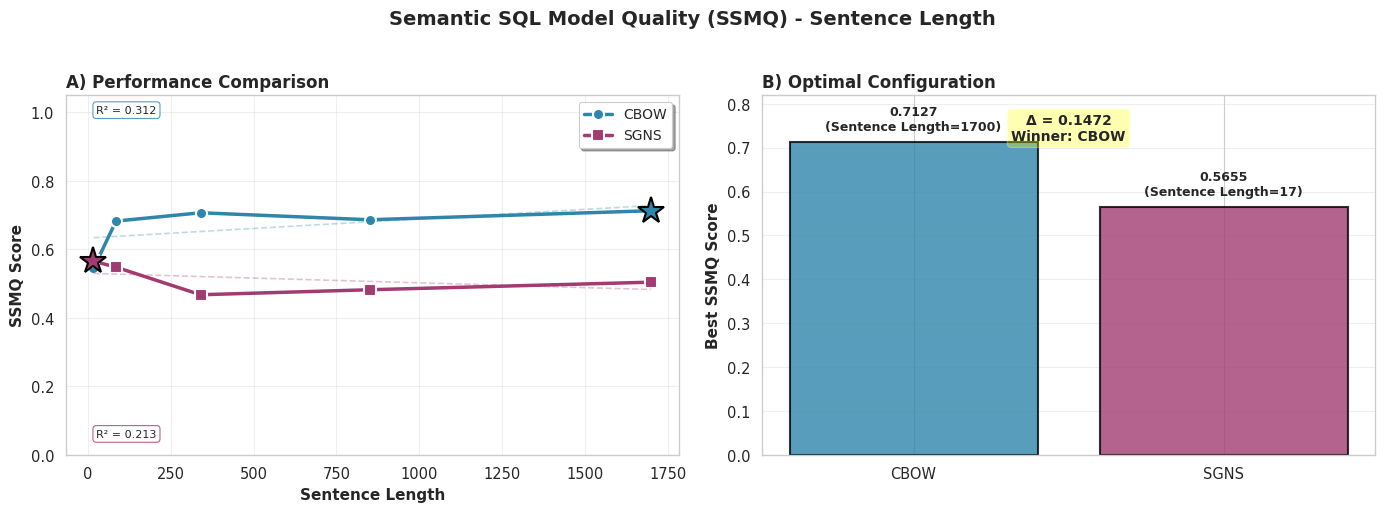


SSMQ SUMMARY - SENTENCE LENGTH
CBOW Best: 0.7127 at Sentence Length=1700
SGNS Best: 0.5655 at Sentence Length=17



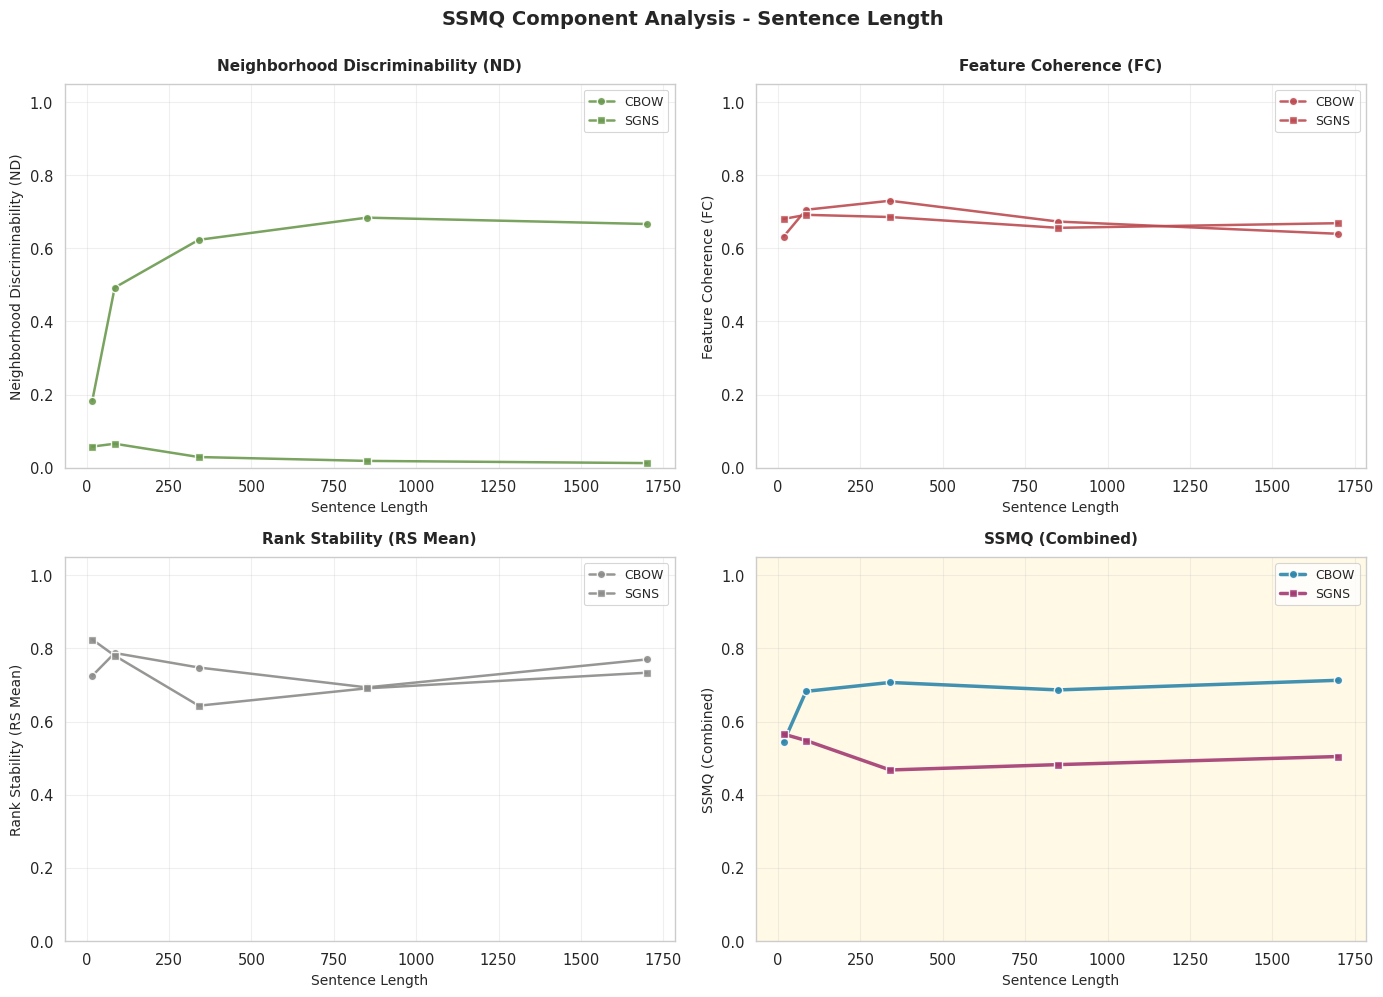


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
17           | 0.1836    0.6322    0.7252    0.5441    | 0.0578    0.6803    0.8242    0.5655   
85           | 0.4925    0.7054    0.7873    0.6825    | 0.0655    0.6915    0.7800    0.5480   
340          | 0.6231    0.7300    0.7477    0.7068    | 0.0292    0.6855    0.6432    0.4675   
850          | 0.6838    0.6731    0.6933    0.6864    | 0.0186    0.6560    0.6907    0.4821   
1700         | 0.6664    0.6396    0.7698    0.7127    | 0.0126    0.6686    0.7334    0.5042   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

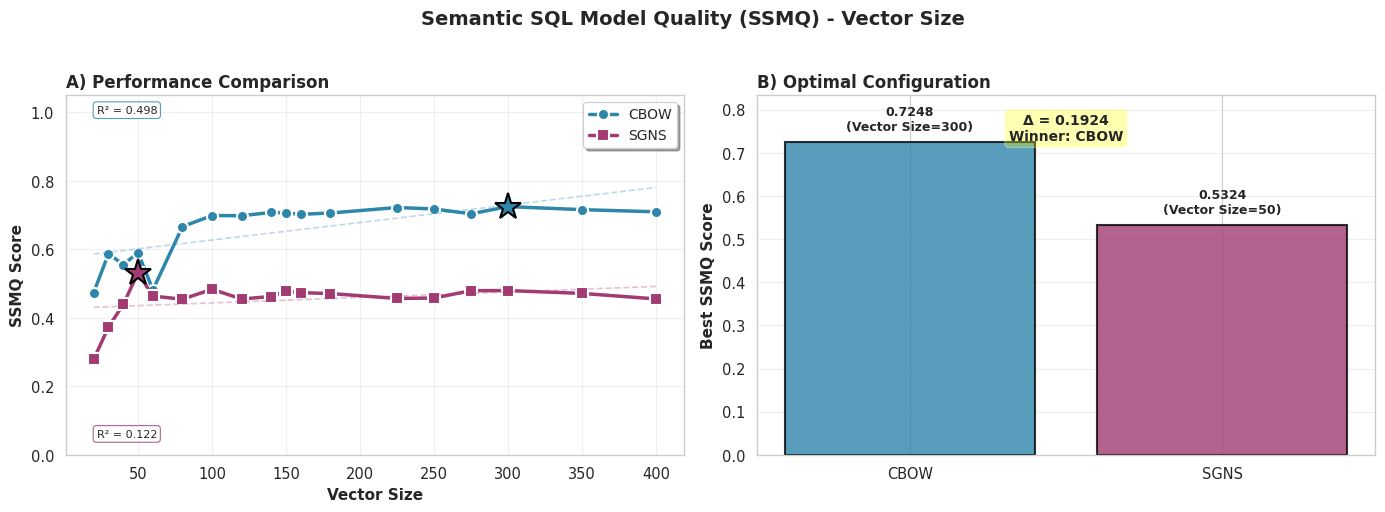


SSMQ SUMMARY - VECTOR SIZE
CBOW Best: 0.7248 at Vector Size=300
SGNS Best: 0.5324 at Vector Size=50



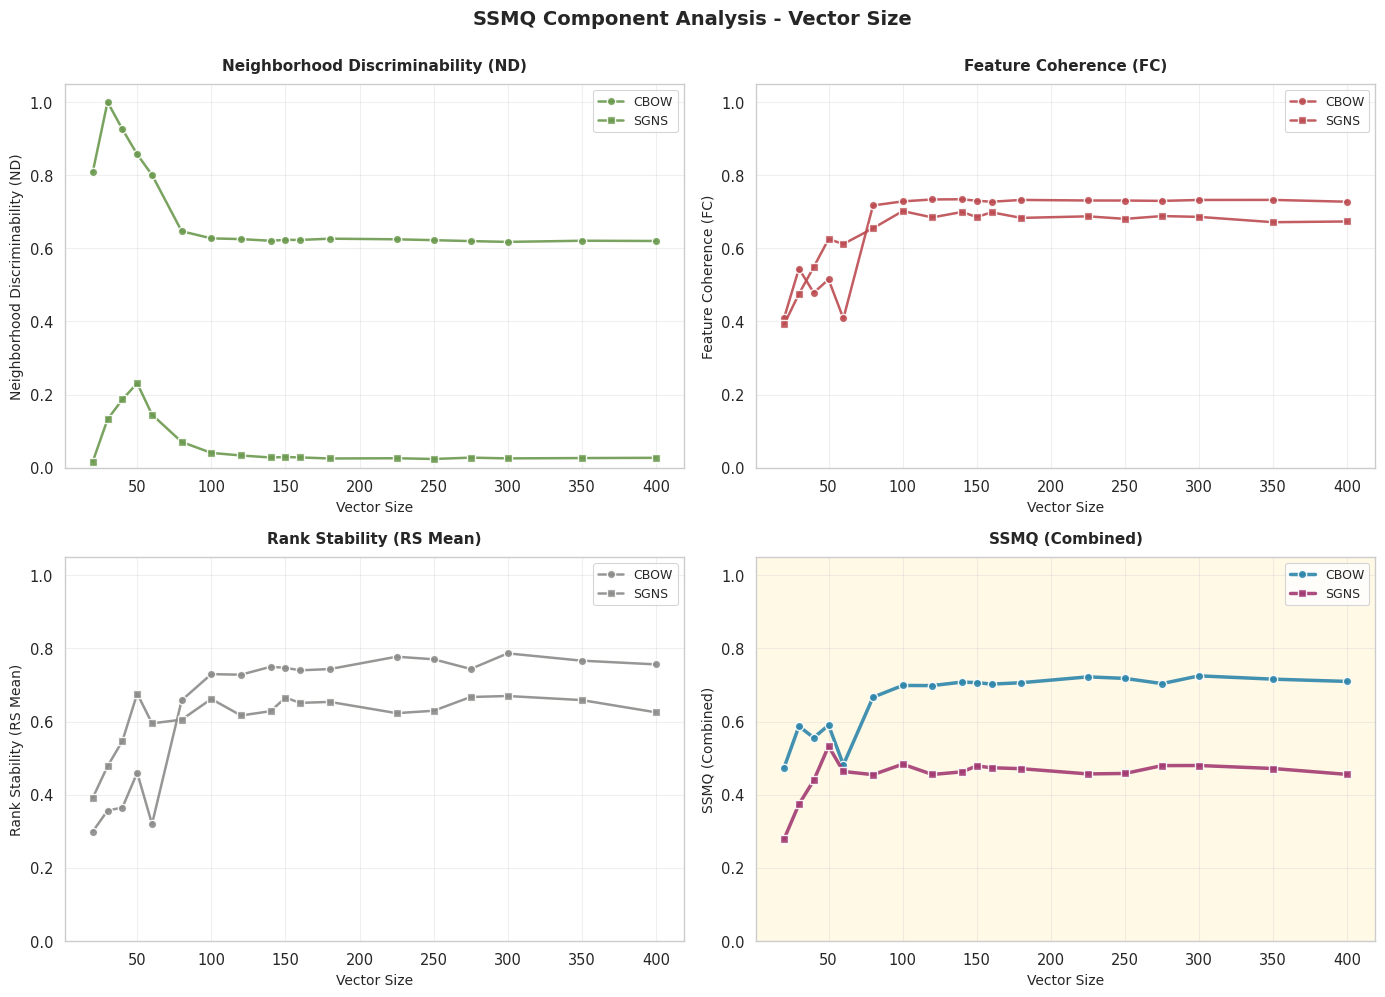


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 0.8084    0.4096    0.2991    0.4740    | 0.0165    0.3918    0.3912    0.2789   
30           | 1.0000    0.5443    0.3565    0.5871    | 0.1323    0.4753    0.4778    0.3736   
40           | 0.9256    0.4784    0.3647    0.5557    | 0.1866    0.5487    0.5466    0.4391   
50           | 0.8569    0.5148    0.4599    0.5900    | 0.2309    0.6251    0.6762    0.5324   
60           | 0.8006    0.4080    0.3198    0.4817    | 0.1451    0.6117    0.5949    0.4633   
80           | 0.6467    0.7172    0.6580    0.6665    | 0.0705    0.6547    0.6051    0.4546   
100          | 0.6272    0.7282    0.7295    0.6986    | 0.0405    0.7017    0.6617   

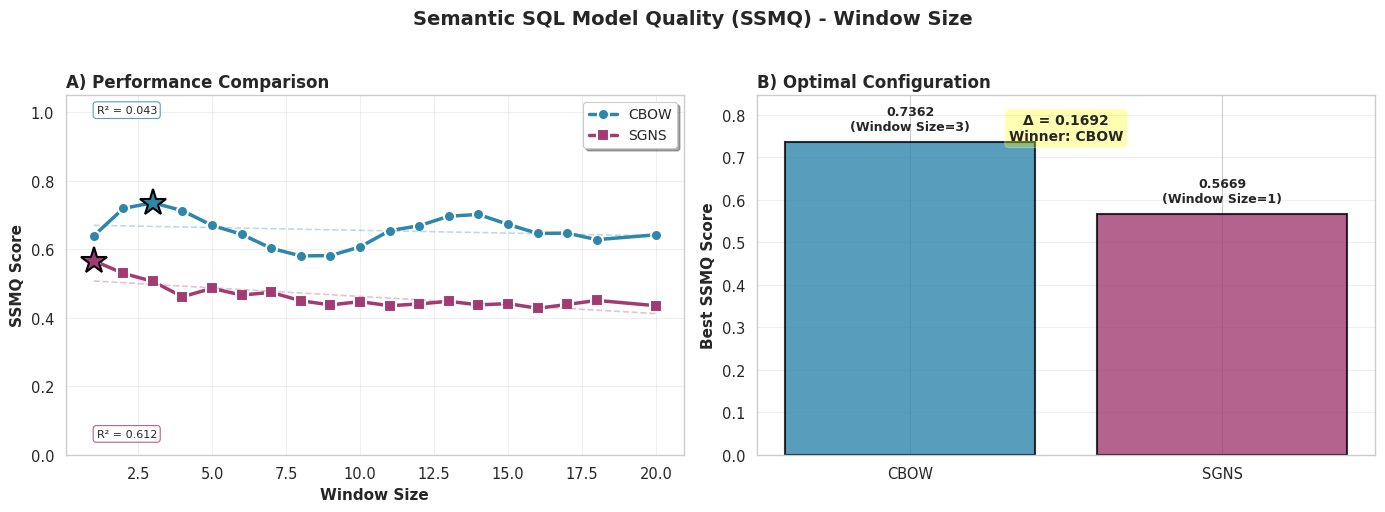


SSMQ SUMMARY - WINDOW SIZE
CBOW Best: 0.7362 at Window Size=3
SGNS Best: 0.5669 at Window Size=1



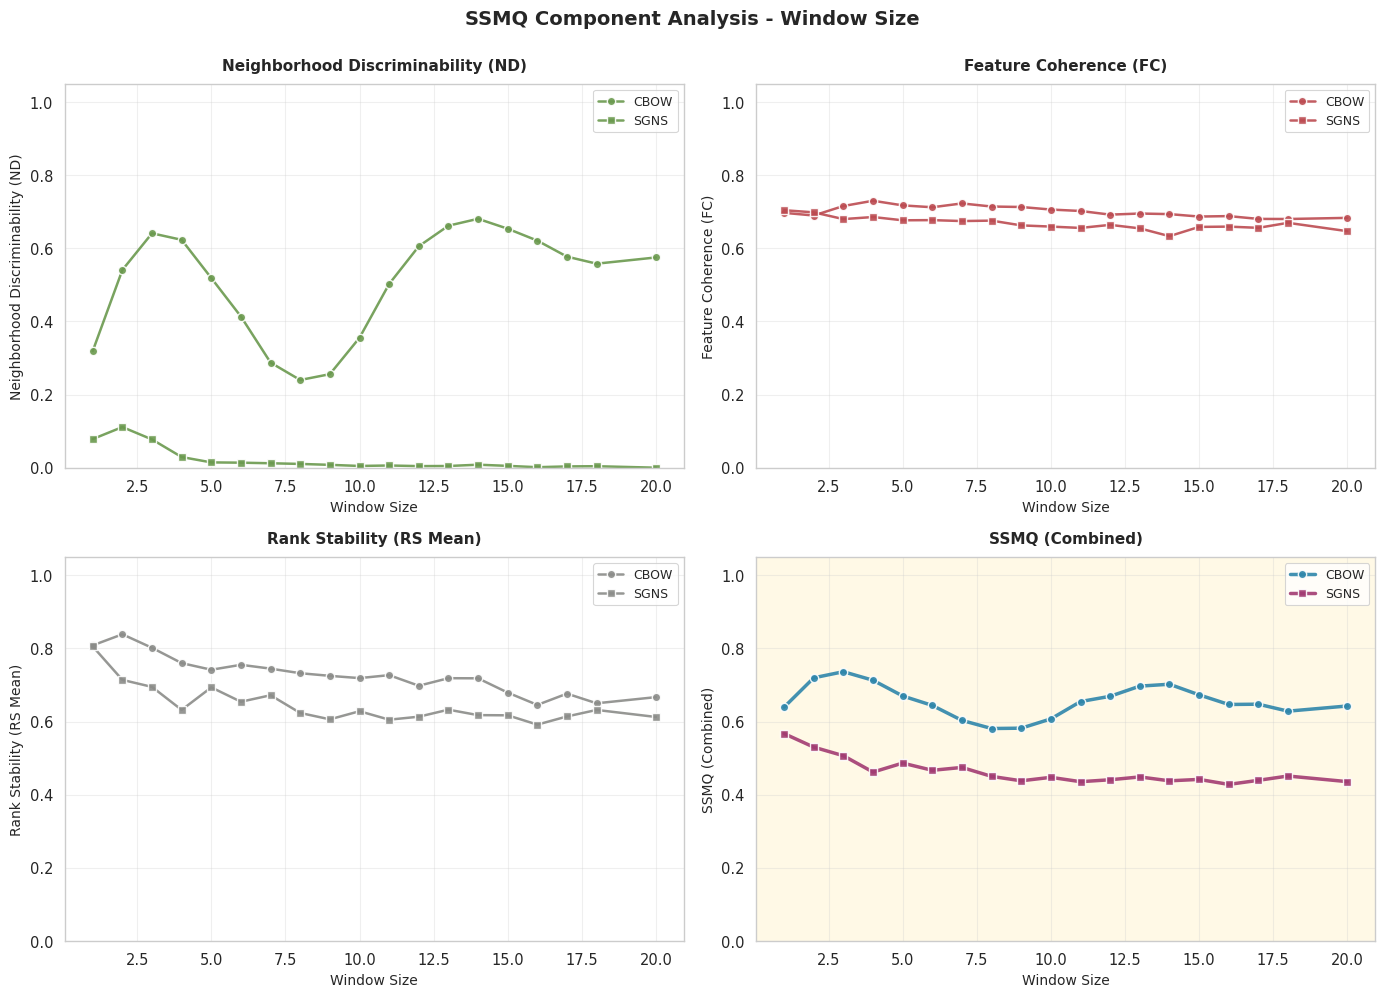


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.3192    0.6969    0.8082    0.6392    | 0.0783    0.7041    0.8052    0.5669   
2            | 0.5408    0.6896    0.8386    0.7195    | 0.1111    0.6983    0.7138    0.5299   
3            | 0.6410    0.7156    0.8015    0.7362    | 0.0773    0.6798    0.6946    0.5064   
4            | 0.6231    0.7300    0.7597    0.7128    | 0.0292    0.6855    0.6317    0.4617   
5            | 0.5186    0.7173    0.7415    0.6698    | 0.0145    0.6765    0.6933    0.4863   
6            | 0.4133    0.7122    0.7551    0.6440    | 0.0137    0.6770    0.6540    0.4665   
7            | 0.2874    0.7227    0.7446    0.6030    | 0.0121    0.6745    0.671

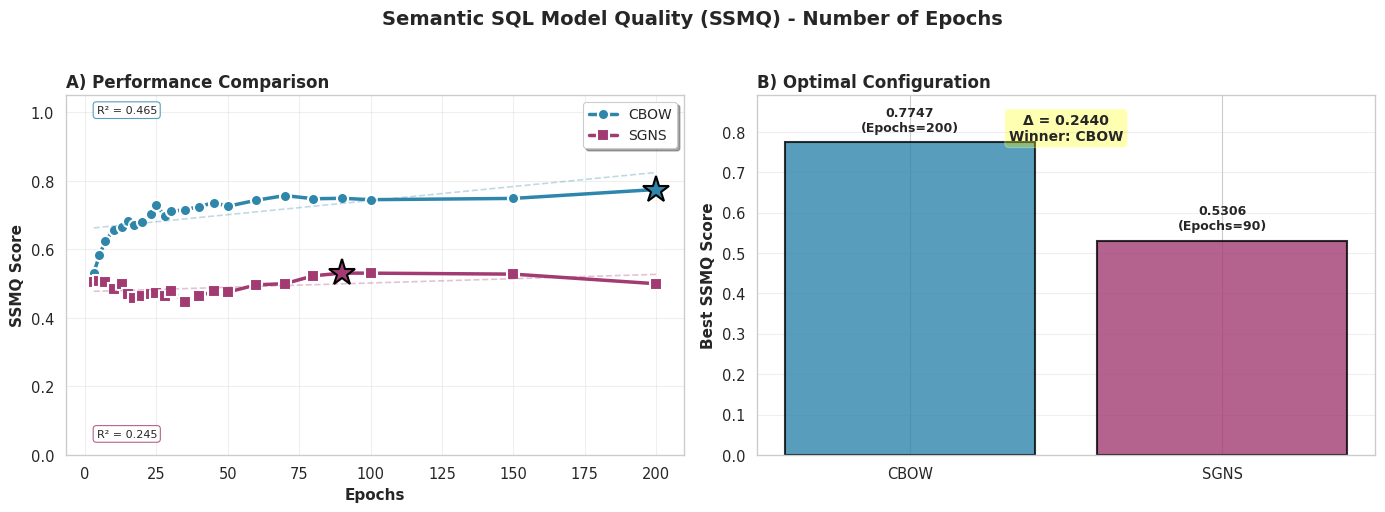


SSMQ SUMMARY - NUMBER OF EPOCHS
CBOW Best: 0.7747 at Epochs=200
SGNS Best: 0.5306 at Epochs=90



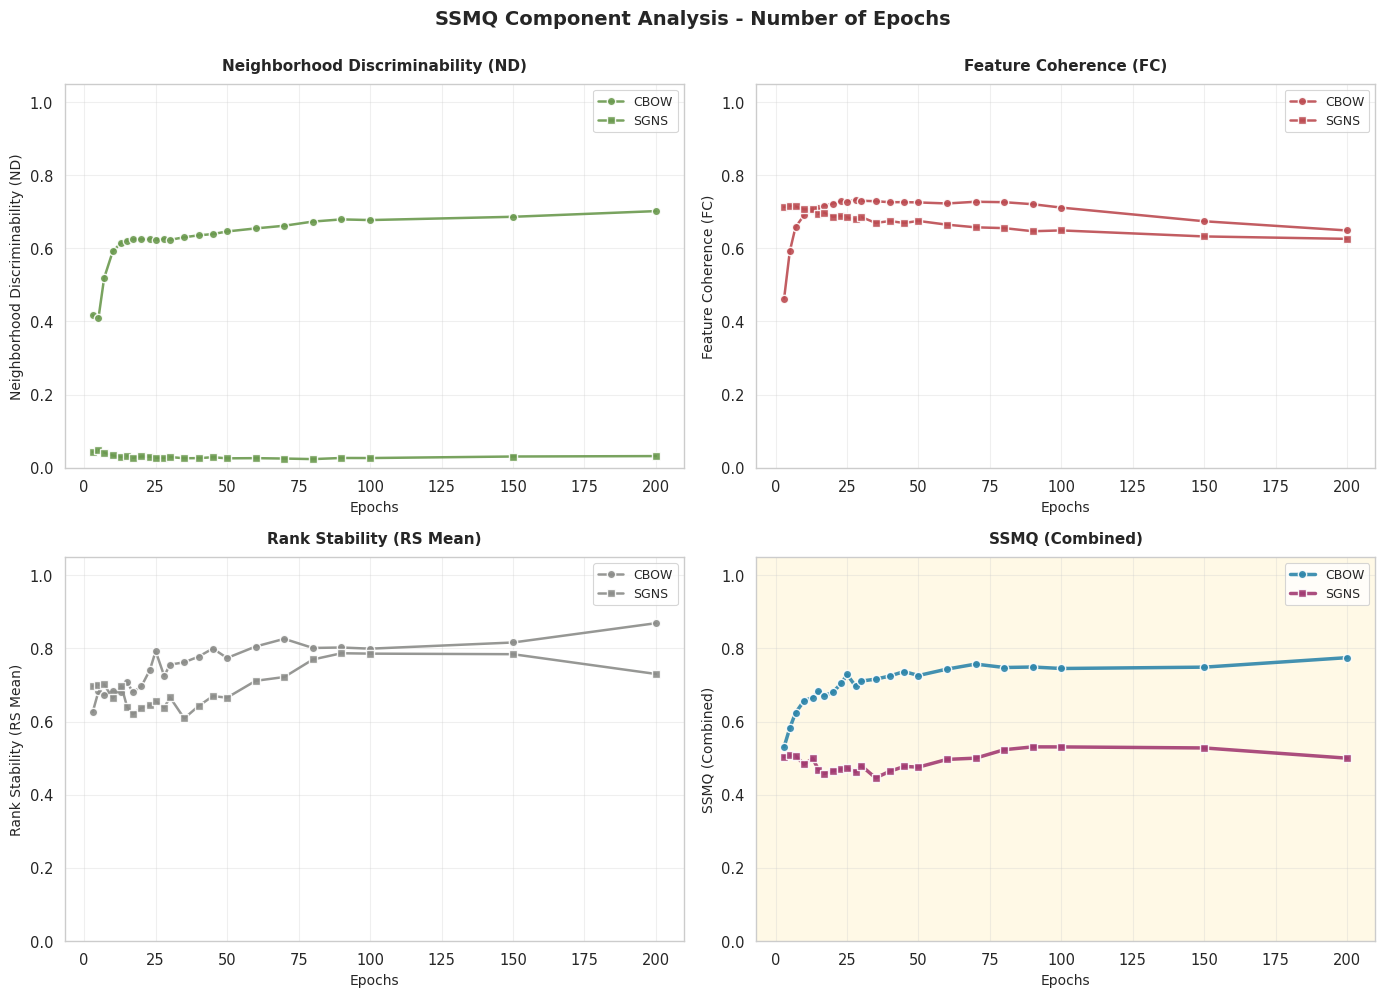


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.4170    0.4624    0.6261    0.5306    | 0.0426    0.7127    0.6965    0.5036   
5            | 0.4090    0.5920    0.6823    0.5822    | 0.0485    0.7160    0.7001    0.5078   
7            | 0.5191    0.6578    0.6726    0.6236    | 0.0411    0.7145    0.7013    0.5059   
10           | 0.5915    0.6908    0.6829    0.6571    | 0.0335    0.7062    0.6633    0.4830   
13           | 0.6156    0.7046    0.6799    0.6655    | 0.0289    0.7065    0.6980    0.4990   
15           | 0.6206    0.7109    0.7085    0.6826    | 0.0322    0.6944    0.6401    0.4686   
17           | 0.6244    0.7168    0.6801    0.6707    | 0.0269    0.6977    0.6199    

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
                transform=ax2.transAxes, ha='center', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Neighborhood Discriminability (ND)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW immer in eigenem Farbton, aber heller
            cbow_color = COLORS['CBOW'] if metric_key == 'ssmq' else metric_color
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS immer in eigenem Farbton, aber heller
            sgns_color = COLORS['SGNS'] if metric_key == 'ssmq' else metric_color
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='lightblue', alpha=0.5, 
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent)
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='lightcoral', alpha=0.5, 
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent)
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    plot_ssmq_main_result(category, category_data, x_label, title_category)
    
    # FIGURE 2: Komponenten-Analyse
    plot_component_analysis(category, category_data, x_label, title_category)
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION


####################################################################################################
# CATEGORY: SENTENCE LENGTH
####################################################################################################



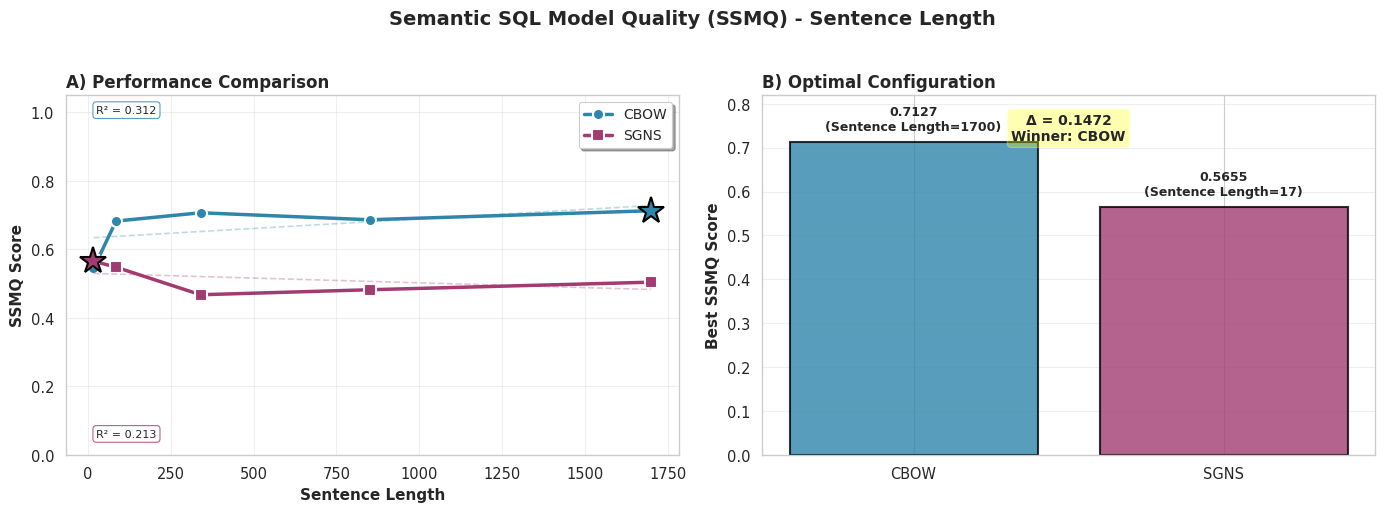


SSMQ SUMMARY - SENTENCE LENGTH
CBOW Best: 0.7127 at Sentence Length=1700
SGNS Best: 0.5655 at Sentence Length=17



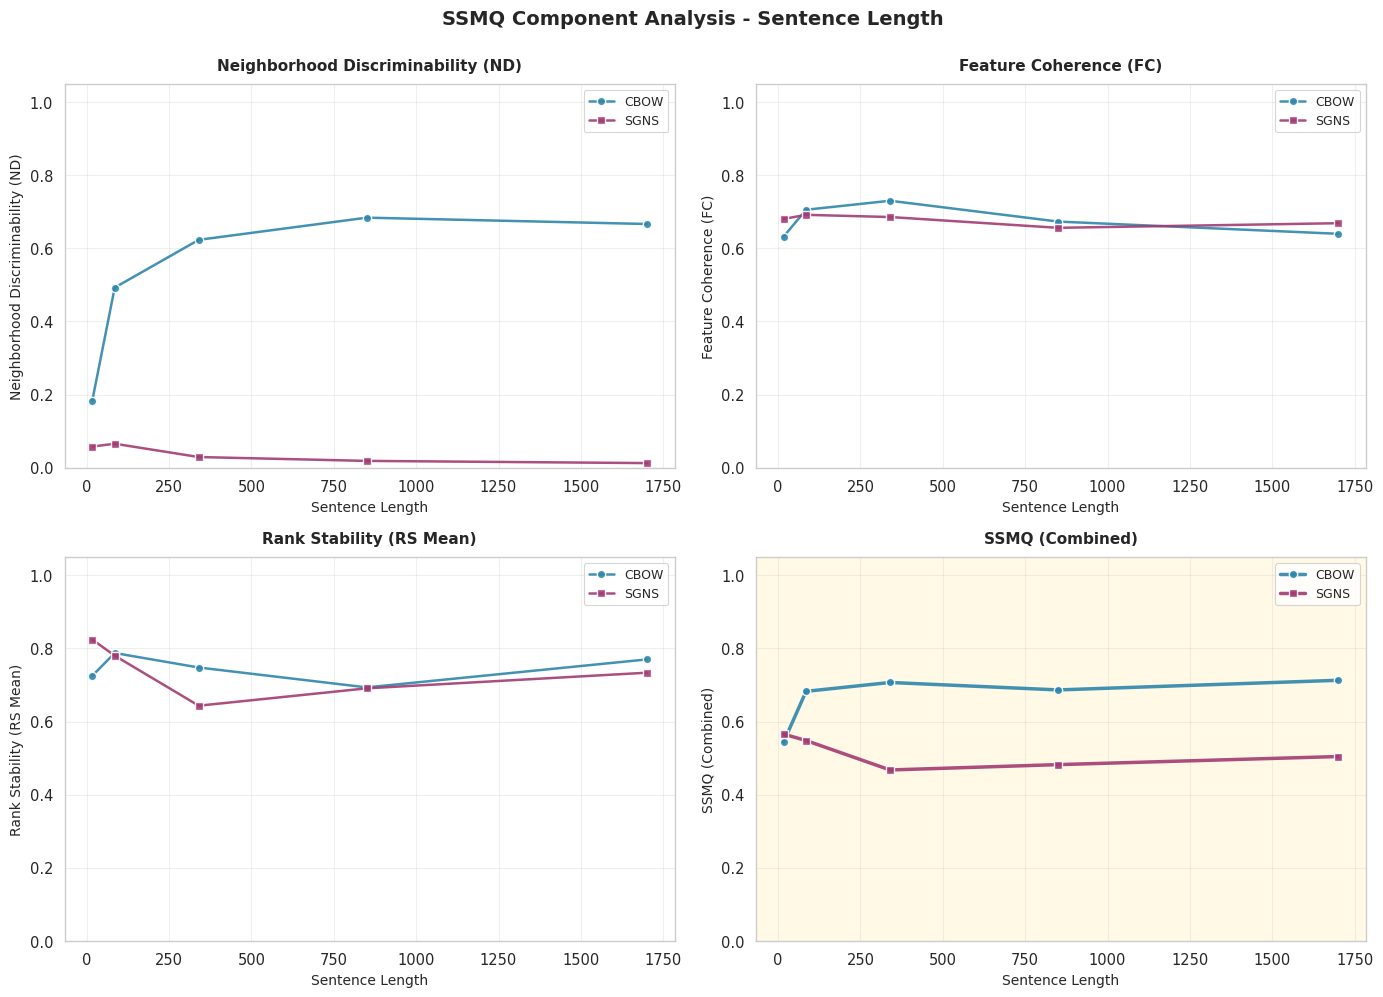


NUMERICAL RESULTS TABLE - SENTENCE

Sentence Length | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
17           | 0.1836    0.6322    0.7252    0.5441    | 0.0578    0.6803    0.8242    0.5655   
85           | 0.4925    0.7054    0.7873    0.6825    | 0.0655    0.6915    0.7800    0.5480   
340          | 0.6231    0.7300    0.7477    0.7068    | 0.0292    0.6855    0.6432    0.4675   
850          | 0.6838    0.6731    0.6933    0.6864    | 0.0186    0.6560    0.6907    0.4821   
1700         | 0.6664    0.6396    0.7698    0.7127    | 0.0126    0.6686    0.7334    0.5042   


####################################################################################################
# CATEGORY: VECTOR SIZE
###################################################

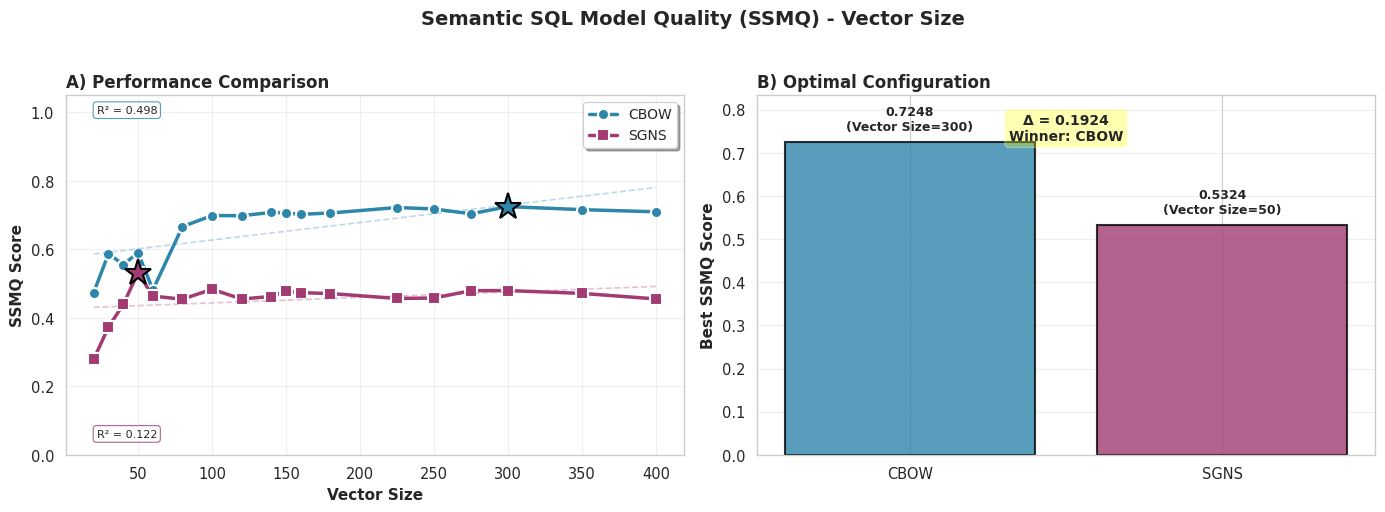


SSMQ SUMMARY - VECTOR SIZE
CBOW Best: 0.7248 at Vector Size=300
SGNS Best: 0.5324 at Vector Size=50



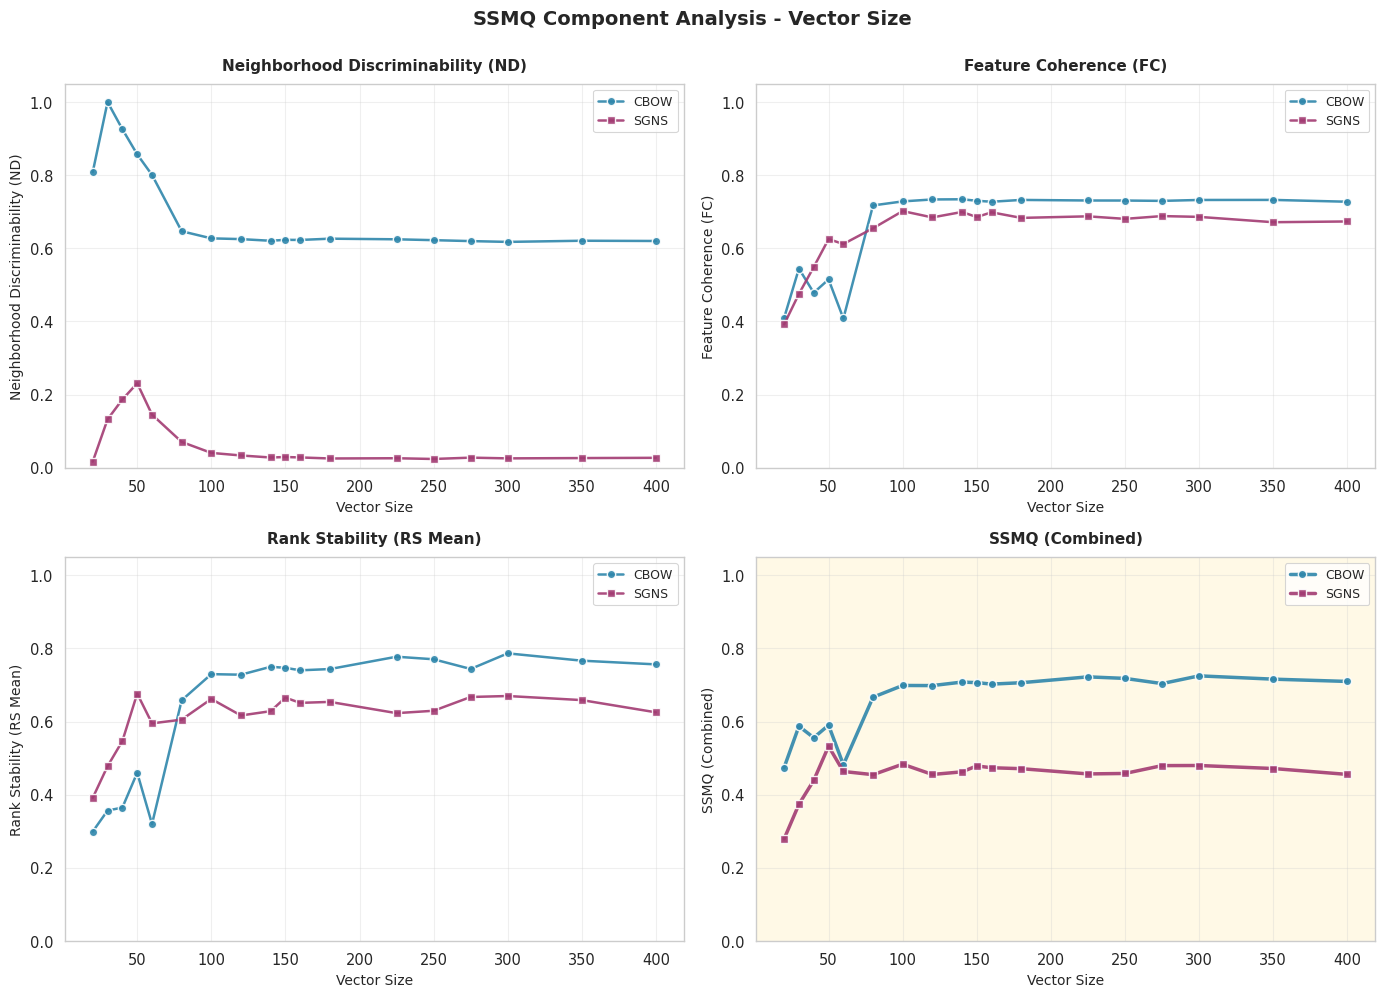


NUMERICAL RESULTS TABLE - VECTOR

Vector Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
20           | 0.8084    0.4096    0.2991    0.4740    | 0.0165    0.3918    0.3912    0.2789   
30           | 1.0000    0.5443    0.3565    0.5871    | 0.1323    0.4753    0.4778    0.3736   
40           | 0.9256    0.4784    0.3647    0.5557    | 0.1866    0.5487    0.5466    0.4391   
50           | 0.8569    0.5148    0.4599    0.5900    | 0.2309    0.6251    0.6762    0.5324   
60           | 0.8006    0.4080    0.3198    0.4817    | 0.1451    0.6117    0.5949    0.4633   
80           | 0.6467    0.7172    0.6580    0.6665    | 0.0705    0.6547    0.6051    0.4546   
100          | 0.6272    0.7282    0.7295    0.6986    | 0.0405    0.7017    0.6617   

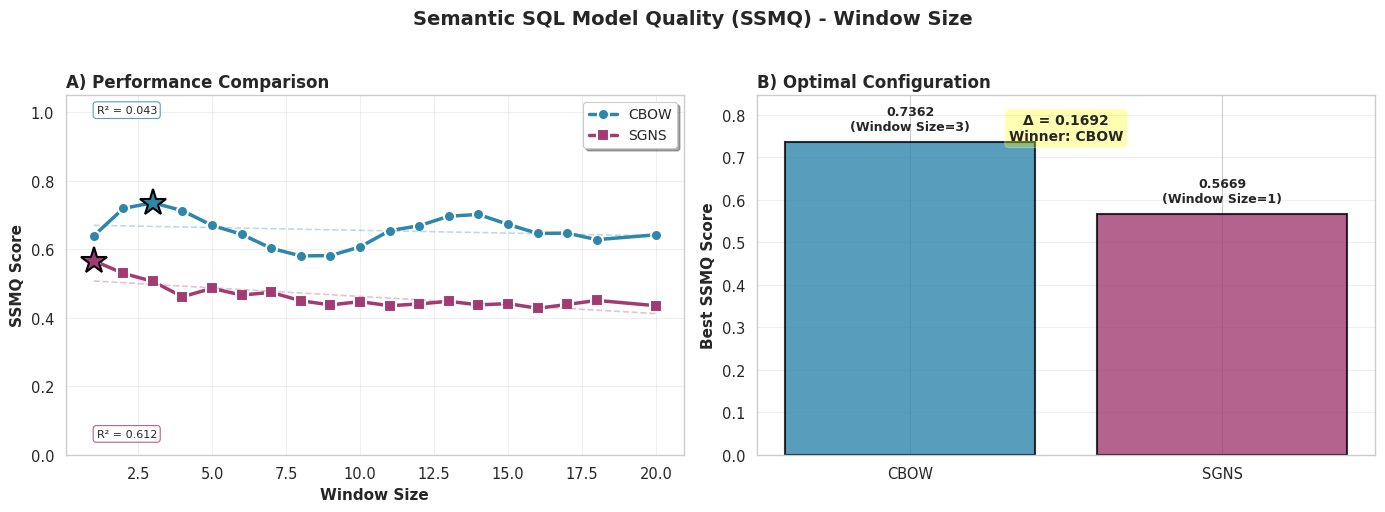


SSMQ SUMMARY - WINDOW SIZE
CBOW Best: 0.7362 at Window Size=3
SGNS Best: 0.5669 at Window Size=1



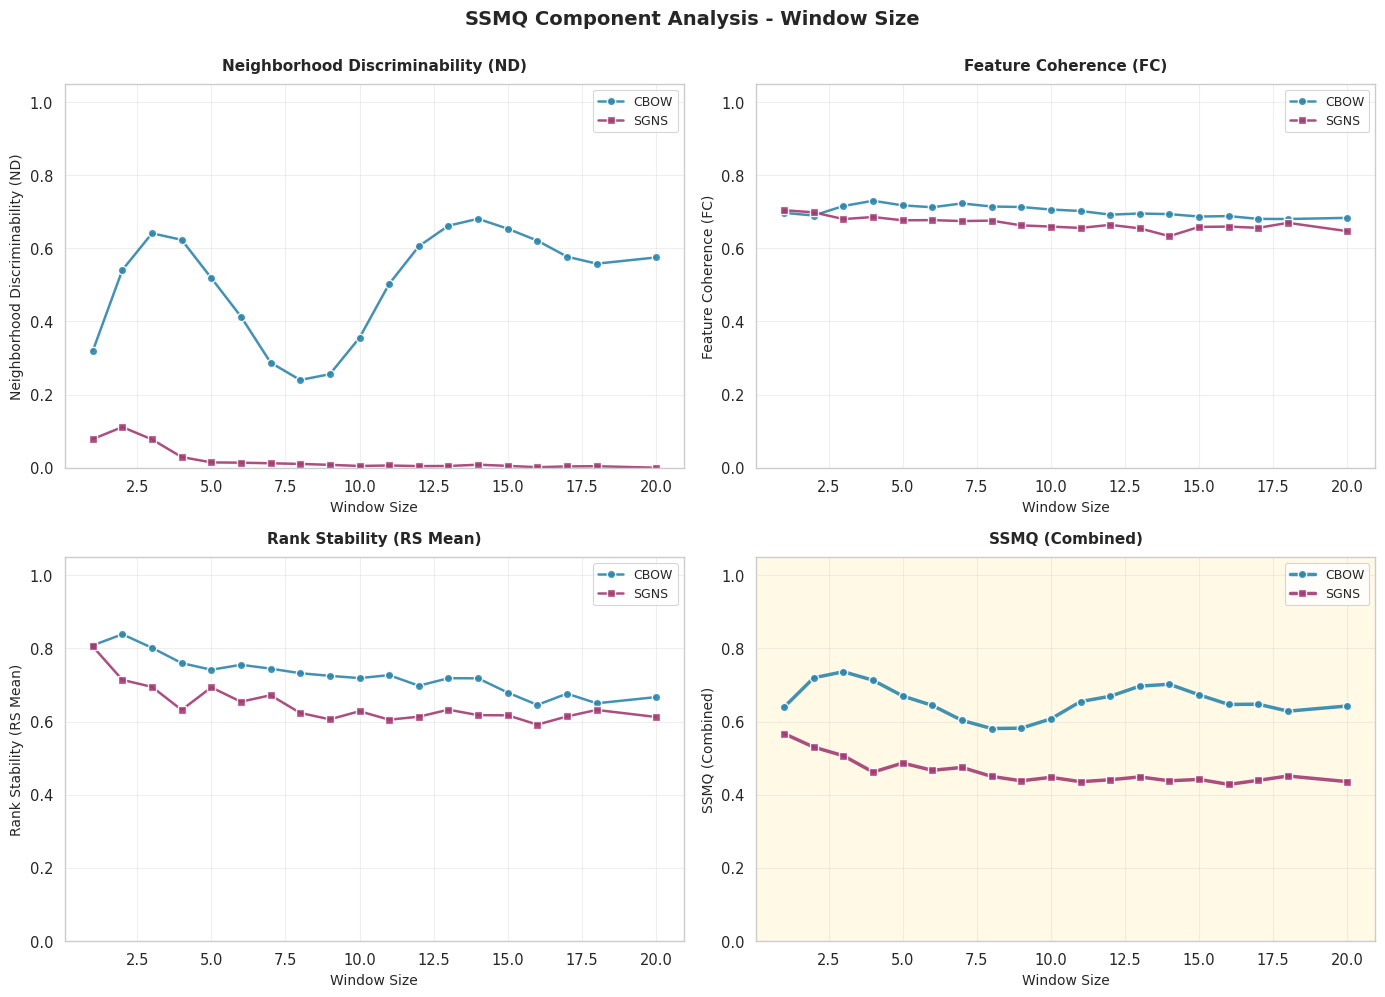


NUMERICAL RESULTS TABLE - WINDOWSIZE

Window Size  | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
1            | 0.3192    0.6969    0.8082    0.6392    | 0.0783    0.7041    0.8052    0.5669   
2            | 0.5408    0.6896    0.8386    0.7195    | 0.1111    0.6983    0.7138    0.5299   
3            | 0.6410    0.7156    0.8015    0.7362    | 0.0773    0.6798    0.6946    0.5064   
4            | 0.6231    0.7300    0.7597    0.7128    | 0.0292    0.6855    0.6317    0.4617   
5            | 0.5186    0.7173    0.7415    0.6698    | 0.0145    0.6765    0.6933    0.4863   
6            | 0.4133    0.7122    0.7551    0.6440    | 0.0137    0.6770    0.6540    0.4665   
7            | 0.2874    0.7227    0.7446    0.6030    | 0.0121    0.6745    0.671

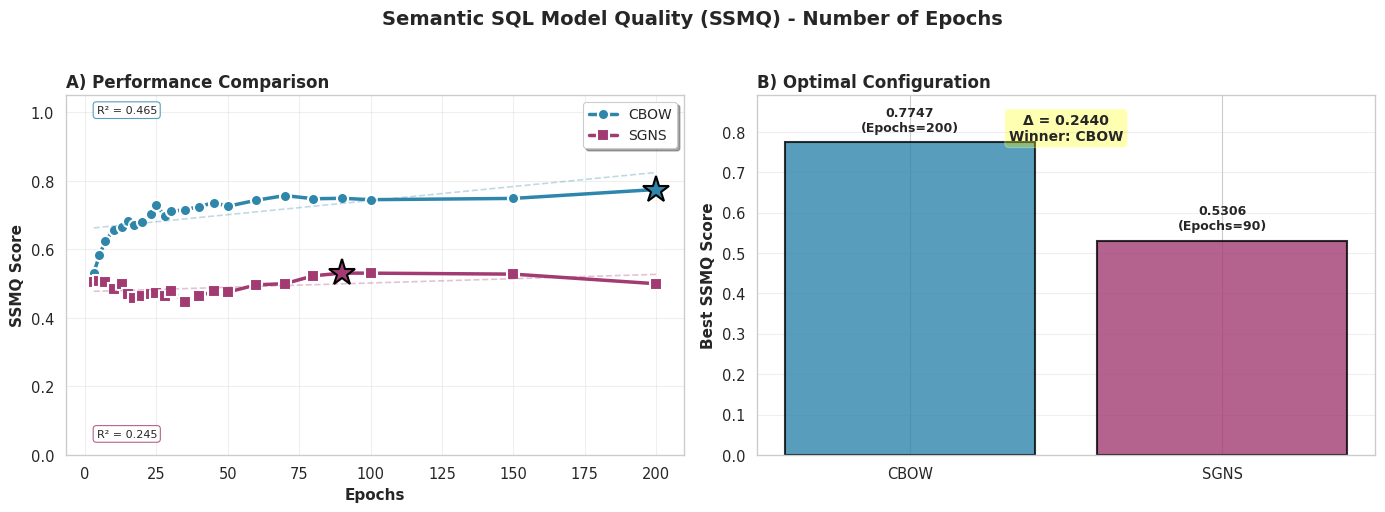


SSMQ SUMMARY - NUMBER OF EPOCHS
CBOW Best: 0.7747 at Epochs=200
SGNS Best: 0.5306 at Epochs=90



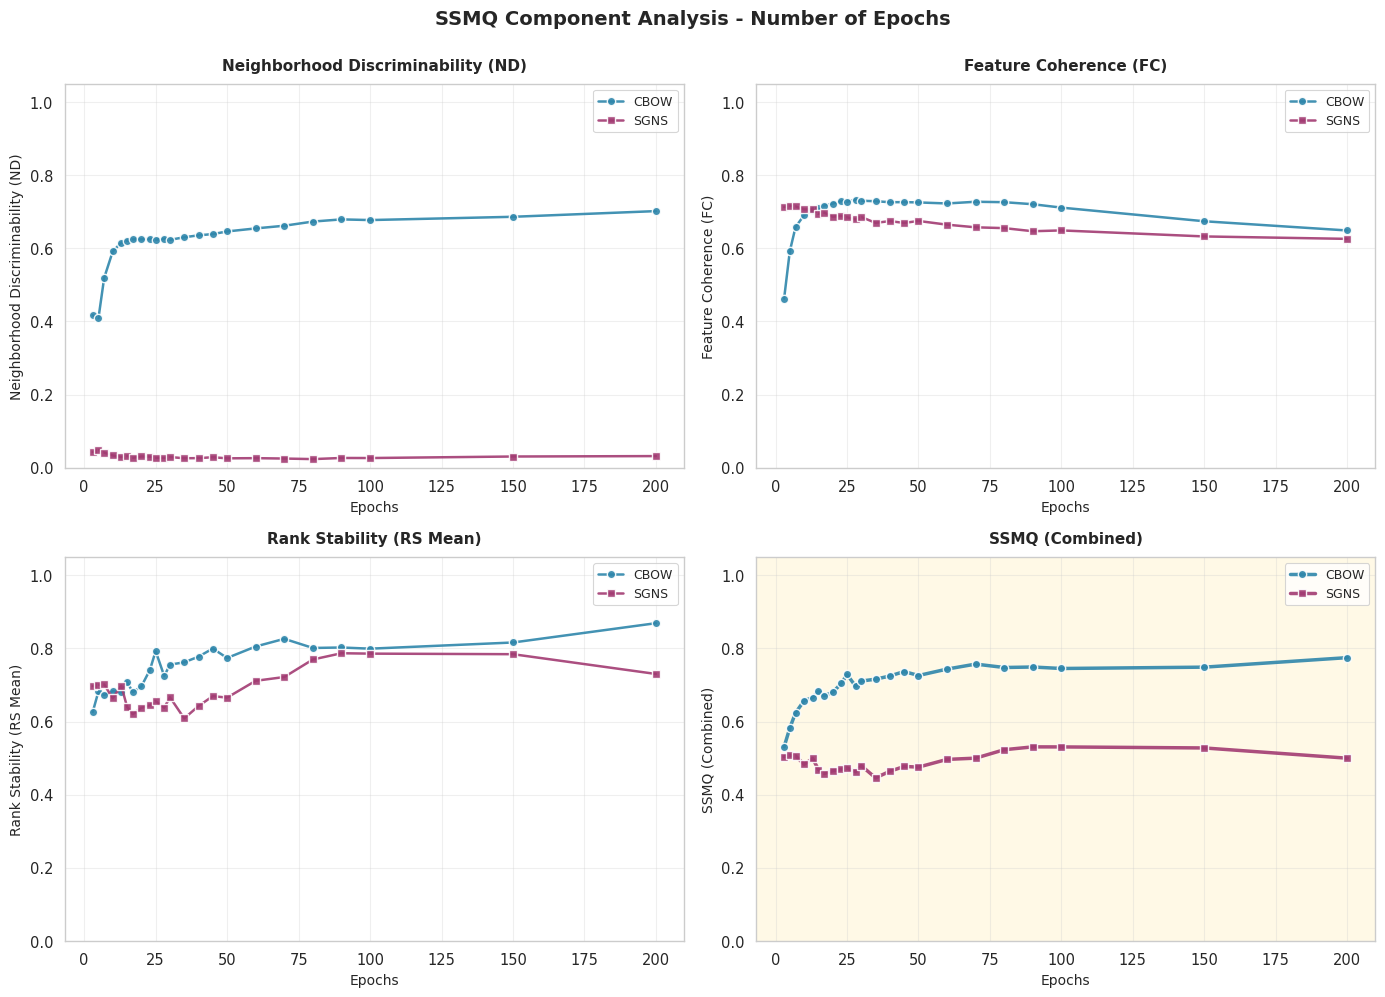


NUMERICAL RESULTS TABLE - EPOCH

Epochs       | CBOW                                     | SGNS                                    
             | ND        FC        RS        SSMQ      | ND        FC        RS        SSMQ     
----------------------------------------------------------------------------------------------------
3            | 0.4170    0.4624    0.6261    0.5306    | 0.0426    0.7127    0.6965    0.5036   
5            | 0.4090    0.5920    0.6823    0.5822    | 0.0485    0.7160    0.7001    0.5078   
7            | 0.5191    0.6578    0.6726    0.6236    | 0.0411    0.7145    0.7013    0.5059   
10           | 0.5915    0.6908    0.6829    0.6571    | 0.0335    0.7062    0.6633    0.4830   
13           | 0.6156    0.7046    0.6799    0.6655    | 0.0289    0.7065    0.6980    0.4990   
15           | 0.6206    0.7109    0.7085    0.6826    | 0.0322    0.6944    0.6401    0.4686   
17           | 0.6244    0.7168    0.6801    0.6707    | 0.0269    0.6977    0.6199    

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import linregress
from scipy import interpolate

# Wissenschaftliches Farbschema - UNVERÄNDERT
COLORS = {
    'CBOW': '#2E86AB',      # Professionelles Blau
    'SGNS': '#A23B72',      # Kontrastierendes Magenta
    'SSMQ': '#F18F01',      # Orange für Wichtigkeit
    'ND': '#6A994E',        # Grün
    'FC': '#BC4B51',        # Rot
    'RS': '#8B8C89'         # Grau
}

# Linienstärken nach Wichtigkeit
LINEWIDTHS = {
    'primary': 2.5,         # SSMQ
    'secondary': 1.8,       # ND, FC, RS_mean
    'tertiary': 1.0         # Hintergrund-Komponenten
}

# Seaborn Style Setup
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Daten nach Kategorien strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # X-Wert und Label bestimmen
    category_mapping = {
        'sentence': ('Satzlänge', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window', 'Window Size'),
        'epoch': ('Epochs', 'Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling'),
        'sample': ('Sample', 'Sample'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Alpha')
    }
    
    if category in category_mapping:
        param_key, x_label = category_mapping[category]
        x_value = result['params'][param_key]
    else:
        x_value = None
        x_label = 'Parameter'
        print(f"Unknown category: {category}")
    
    # Metriken extrahieren
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    metrics_dict = {
        'nd': nd_value,
        'rs_mean': float(result['rs_mean']) if 'rs_mean' in result else None,
        'rs_5': float(result['rs_5']) if 'rs_5' in result else None,
        'rs_10': float(result['rs_10']) if 'rs_10' in result else None,
        'rs_20': float(result['rs_20']) if 'rs_20' in result else None,
        'fc': float(result['fc']) if 'fc' in result else None,
        'ssmq': float(result['ssmq']) if 'ssmq' in result else None
    }
    
    if x_value is not None:
        for metric_name, metric_value in metrics_dict.items():
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value


def add_trend_analysis(x_values, y_values, ax, color, position='top'):
    """Fügt Trendlinie und R² hinzu"""
    if len(x_values) >= 3:
        slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values)
        trend_line = slope * np.array(x_values) + intercept
        ax.plot(x_values, trend_line, '--', color=color, alpha=0.3, linewidth=1.2)
        
        y_pos = 0.95 if position == 'top' else 0.05
        ax.text(0.05, y_pos, f'R² = {r_value**2:.3f}', 
                transform=ax.transAxes, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=color))


def plot_ssmq_main_result(category, category_data, x_label, title_category):
    """
    FIGURE 1: SSMQ Hauptergebnis (Das wichtigste Ergebnis)
    Panel A: Line Plot mit Trends
    Panel B: Best Performance Bar Chart
    """
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    if not cbow_ssmq_data and not sgns_ssmq_data:
        print(f"No SSMQ data for {category}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Semantic SQL Model Quality (SSMQ) - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    # Panel A: Line Plot mit Trends - UNVERÄNDERT (schon richtig)
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='CBOW', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_cbow, y_cbow, ax1, COLORS['CBOW'], 'top')
        
        # Markiere Maximum
        max_idx = np.argmax(y_cbow)
        ax1.plot(x_cbow[max_idx], y_cbow[max_idx], '*', 
                color=COLORS['CBOW'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['primary'], markersize=8, 
                label='SGNS', markeredgecolor='white', markeredgewidth=1.5)
        add_trend_analysis(x_sgns, y_sgns, ax1, COLORS['SGNS'], 'bottom')
        
        # Markiere Maximum
        max_idx = np.argmax(y_sgns)
        ax1.plot(x_sgns[max_idx], y_sgns[max_idx], '*', 
                color=COLORS['SGNS'], markersize=20, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('SSMQ Score', fontsize=11, fontweight='bold')
    ax1.set_title('A) Performance Comparison', fontsize=12, loc='left', fontweight='bold')
    ax1.legend(fontsize=10, frameon=True, shadow=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # Panel B: Best Performance Comparison
    if cbow_ssmq_data and sgns_ssmq_data:
        max_cbow = max(cbow_ssmq_data.values())
        max_sgns = max(sgns_ssmq_data.values())
        max_cbow_param = max(cbow_ssmq_data, key=cbow_ssmq_data.get)
        max_sgns_param = max(sgns_ssmq_data, key=sgns_ssmq_data.get)
        
        algorithms = ['CBOW', 'SGNS']
        scores = [max_cbow, max_sgns]
        params = [max_cbow_param, max_sgns_param]
        colors_list = [COLORS['CBOW'], COLORS['SGNS']]
        
        bars = ax2.bar(algorithms, scores, color=colors_list, alpha=0.8, 
                      edgecolor='black', linewidth=1.5)
        
        # Werte auf Balken
        for bar, score, param in zip(bars, scores, params):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{score:.4f}\n({x_label}={param})',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax2.set_ylabel('Best SSMQ Score', fontsize=11, fontweight='bold')
        ax2.set_title('B) Optimal Configuration', fontsize=12, loc='left', fontweight='bold')
        ax2.set_ylim([0, max(scores) * 1.15])
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Differenz anzeigen
        diff = abs(max_cbow - max_sgns)
        winner = 'CBOW' if max_cbow > max_sgns else 'SGNS'
        ax2.text(0.5, 0.95, f'Δ = {diff:.4f}\nWinner: {winner}',
                transform=ax2.transAxes, ha='center', va='top',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print(f"\n{'='*80}")
    print(f"SSMQ SUMMARY - {title_category.upper()}")
    print(f"{'='*80}")
    if cbow_ssmq_data:
        print(f"CBOW Best: {max(cbow_ssmq_data.values()):.4f} at {x_label}={max(cbow_ssmq_data, key=cbow_ssmq_data.get)}")
    if sgns_ssmq_data:
        print(f"SGNS Best: {max(sgns_ssmq_data.values()):.4f} at {x_label}={max(sgns_ssmq_data, key=sgns_ssmq_data.get)}")
    print(f"{'='*80}\n")


def plot_component_analysis(category, category_data, x_label, title_category):
    """
    FIGURE 2: Komponenten-Analyse
    Zeigt wie sich SSMQ aus ND, FC und RS zusammensetzt
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'SSMQ Component Analysis - {title_category}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    metrics_config = [
        ('nd', 'Neighborhood Discriminability (ND)', COLORS['ND'], axes[0, 0]),
        ('fc', 'Feature Coherence (FC)', COLORS['FC'], axes[0, 1]),
        ('rs_mean', 'Rank Stability (RS Mean)', COLORS['RS'], axes[1, 0]),
        ('ssmq', 'SSMQ (Combined)', COLORS['SSMQ'], axes[1, 1])
    ]
    
    for metric_key, metric_title, metric_color, ax in metrics_config:
        cbow_data = category_data['CBOW'][metric_key]
        sgns_data = category_data['SGNS'][metric_key]
        
        has_data = False
        
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            
            # CBOW: Immer professionelles Blau für alle Metriken
            cbow_color = COLORS['CBOW']  # Jetzt immer CBOW-Blau
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_cbow, y_cbow, '-o', color=cbow_color, 
                   linewidth=linewidth, markersize=6, label='CBOW',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            
            # SGNS: Immer kontrastierendes Magenta für alle Metriken
            sgns_color = COLORS['SGNS']  # Jetzt immer SGNS-Magenta
            linewidth = LINEWIDTHS['primary'] if metric_key == 'ssmq' else LINEWIDTHS['secondary']
            
            ax.plot(x_sgns, y_sgns, '-s', color=sgns_color, 
                   linewidth=linewidth, markersize=6, label='SGNS',
                   alpha=0.9, markeredgecolor='white', markeredgewidth=1)
            has_data = True
        
        if has_data:
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel(metric_title, fontsize=10)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
            ax.legend(fontsize=9, frameon=True)
            ax.grid(True, alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            # Für SSMQ: Hervorhebung
            if metric_key == 'ssmq':
                ax.set_facecolor('#FFF9E6')  # Leichter gelber Hintergrund
        else:
            ax.text(0.5, 0.5, f'No {metric_key.upper()} data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(metric_title, fontsize=11, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.show()


def plot_rank_stability_details(category, category_data, x_label, title_category):
    """
    OPTIONAL FIGURE 3: Detaillierte Rank Stability Analyse
    Nur wenn RS-Komponenten relevant sind
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Rank Stability Details - {title_category}', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    rs_components = ['rs_5', 'rs_10', 'rs_20']
    rs_labels = ['RS @5', 'RS @10', 'RS @20']
    rs_styles = [':', '--', '-.']
    
    # CBOW RS Components - Jetzt in hellen Blautönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['CBOW'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax1.plot(x, y, style, color='#87CEEB', alpha=0.7,  # Heller Blauton für CBOW
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # CBOW RS Mean (prominent) - Jetzt in voller CBOW-Farbe
    cbow_mean_data = category_data['CBOW']['rs_mean']
    if cbow_mean_data:
        x = sorted(cbow_mean_data.keys())
        y = [cbow_mean_data[xi] for xi in x]
        ax1.plot(x, y, '-o', color=COLORS['CBOW'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax1.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax1.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax1.set_title('CBOW - Rank Stability', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, frameon=True)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])
    
    # SGNS RS Components - Jetzt in hellen Magentatönen
    for i, (rs_key, rs_label, style) in enumerate(zip(rs_components, rs_labels, rs_styles)):
        data = category_data['SGNS'][rs_key]
        if data:
            x = sorted(data.keys())
            y = [data[xi] for xi in x]
            ax2.plot(x, y, style, color='#FFB6C1', alpha=0.7,  # Heller Magentaton für SGNS
                    linewidth=LINEWIDTHS['tertiary'], label=rs_label)
    
    # SGNS RS Mean (prominent) - Jetzt in voller SGNS-Farbe
    sgns_mean_data = category_data['SGNS']['rs_mean']
    if sgns_mean_data:
        x = sorted(sgns_mean_data.keys())
        y = [sgns_mean_data[xi] for xi in x]
        ax2.plot(x, y, '-s', color=COLORS['SGNS'], 
                linewidth=LINEWIDTHS['secondary'], markersize=8, 
                label='RS Mean', markeredgecolor='white', markeredgewidth=1.5)
    
    ax2.set_xlabel(x_label, fontsize=11, fontweight='bold')
    ax2.set_ylabel('RS Score', fontsize=11, fontweight='bold')
    ax2.set_title('SGNS - Rank Stability', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, frameon=True)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    plt.show()


def create_summary_table(category, category_data, x_label):
    """
    Erstellt formatierte Tabelle für wissenschaftliche Arbeit
    """
    print(f"\n{'='*100}")
    print(f"NUMERICAL RESULTS TABLE - {category.upper()}")
    print(f"{'='*100}")
    
    # Sammle alle x-Werte
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'rs_mean', 'ssmq']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if not sorted_x:
        print("No data available")
        return
    
    # Header
    print(f"\n{x_label:<12} | {'CBOW':<40} | {'SGNS':<40}")
    print(f"{'':<12} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9} | {'ND':<9} {'FC':<9} {'RS':<9} {'SSMQ':<9}")
    print("-" * 100)
    
    # Datenzeilen
    for x in sorted_x:
        cbow_nd = category_data['CBOW']['nd'].get(x, None)
        cbow_fc = category_data['CBOW']['fc'].get(x, None)
        cbow_rs = category_data['CBOW']['rs_mean'].get(x, None)
        cbow_ssmq = category_data['CBOW']['ssmq'].get(x, None)
        
        sgns_nd = category_data['SGNS']['nd'].get(x, None)
        sgns_fc = category_data['SGNS']['fc'].get(x, None)
        sgns_rs = category_data['SGNS']['rs_mean'].get(x, None)
        sgns_ssmq = category_data['SGNS']['ssmq'].get(x, None)
        
        def fmt(val):
            return f"{val:.4f}" if val is not None else "N/A"
        
        print(f"{str(x):<12} | {fmt(cbow_nd):<9} {fmt(cbow_fc):<9} {fmt(cbow_rs):<9} {fmt(cbow_ssmq):<9} | "
              f"{fmt(sgns_nd):<9} {fmt(sgns_fc):<9} {fmt(sgns_rs):<9} {fmt(sgns_ssmq):<9}")
    
    print(f"{'='*100}\n")


# Hauptschleife: Erzeuge Plots für jede Kategorie
print("\n" + "="*100)
print("WORD2VEC PARAMETER SWEEP ANALYSIS - SCIENTIFIC VISUALIZATION")
print("="*100 + "\n")

for category, category_data in data_by_category.items():
    # Label-Mapping
    category_mapping = {
        'sentence': ('Sentence Length', 'Sentence Length'),
        'vector': ('Vector Size', 'Vector Size'),
        'windowsize': ('Window Size', 'Window Size'),
        'epoch': ('Epochs', 'Number of Epochs'),
        'negative': ('Negative Sampling', 'Negative Sampling Size'),
        'sample': ('Sample', 'Subsampling Threshold'),
        'hs': ('Hierarchical Softmax', 'Hierarchical Softmax'),
        'alpha': ('Alpha', 'Learning Rate (Alpha)')
    }
    
    x_label, title_category = category_mapping.get(category, ('Parameter', category))
    
    print(f"\n{'#'*100}")
    print(f"# CATEGORY: {title_category.upper()}")
    print(f"{'#'*100}\n")
    
    # FIGURE 1: Hauptergebnis SSMQ
    plot_ssmq_main_result(category, category_data, x_label, title_category)
    
    # FIGURE 2: Komponenten-Analyse
    plot_component_analysis(category, category_data, x_label, title_category)
    
    # OPTIONAL FIGURE 3: RS Details (nur wenn interessant)
    # plot_rank_stability_details(category, category_data, x_label, title_category)
    
    # TABLE: Numerische Ergebnisse
    create_summary_table(category, category_data, x_label)

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)


TOP 10 WORD2VEC MODELS BY SSMQ SCORE



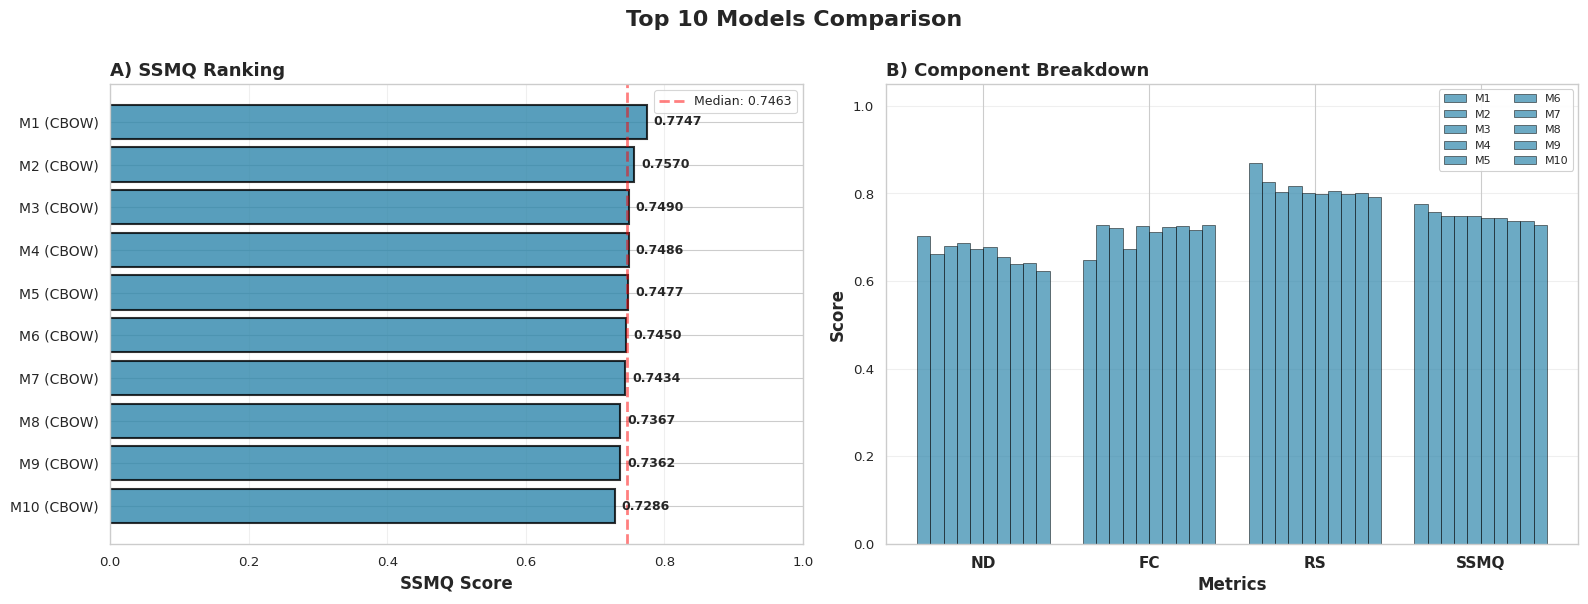

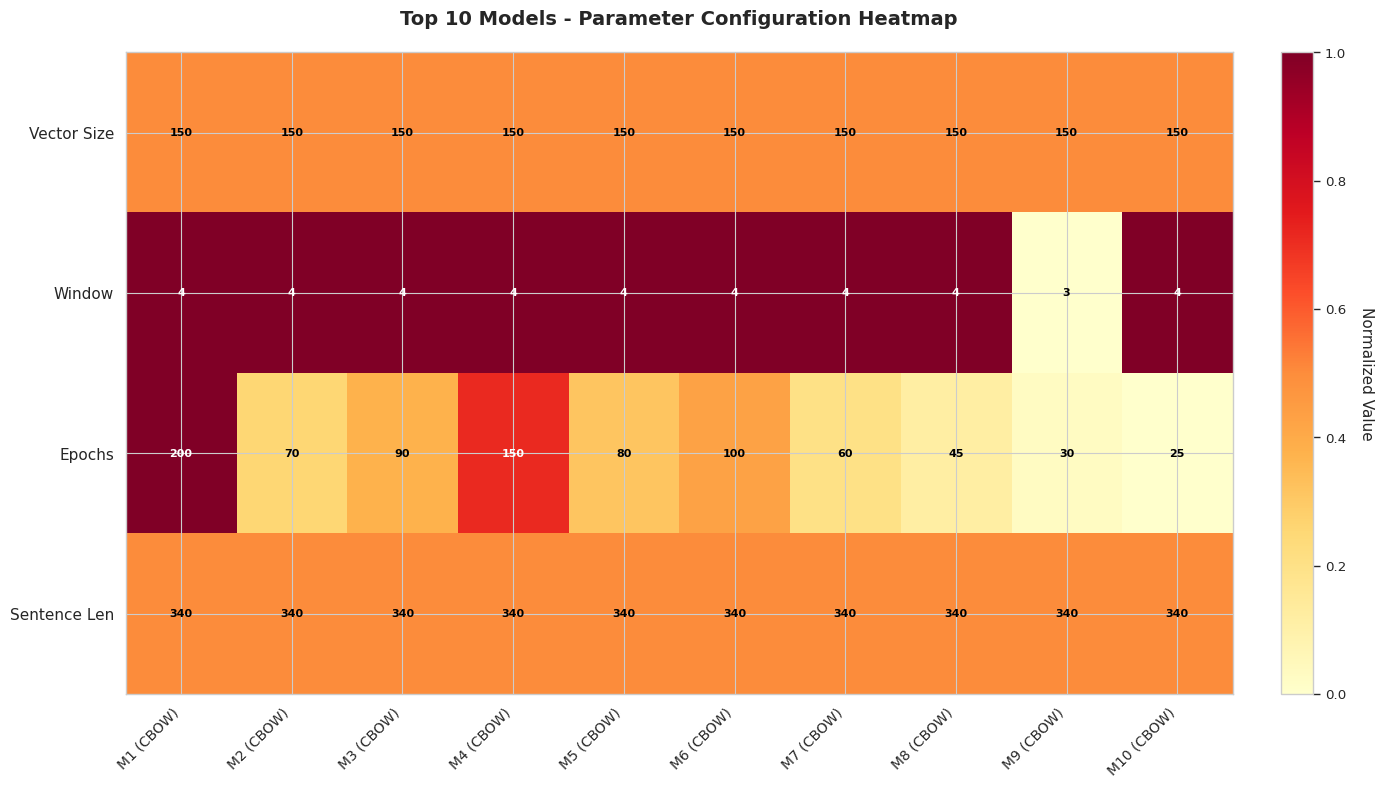


TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)

Model Algorithm   SSMQ     ND     FC     RS  Vec  Win  Epoch
   M1      CBOW 0.7747 0.7017 0.6487 0.8688  150    4    200
   M2      CBOW 0.7570 0.6617 0.7272 0.8261  150    4     70
   M3      CBOW 0.7490 0.6790 0.7205 0.8024  150    4     90
   M4      CBOW 0.7486 0.6861 0.6739 0.8161  150    4    150
   M5      CBOW 0.7477 0.6731 0.7261 0.8011  150    4     80
   M6      CBOW 0.7450 0.6772 0.7112 0.7992  150    4    100
   M7      CBOW 0.7434 0.6544 0.7226 0.8051  150    4     60
   M8      CBOW 0.7367 0.6389 0.7262 0.7996  150    4     45
   M9      CBOW 0.7362 0.6410 0.7156 0.8015  150    3     30
  M10      CBOW 0.7286 0.6232 0.7275 0.7923  150    4     25


LaTeX Table Code:
--------------------------------------------------------------------------------
\begin{tabular}{llllllrrr}
\toprule
Model & Algorithm & SSMQ & ND & FC & RS & Vec & Win & Epoch \\
\midrule
M1 & CBOW & 0.7747 & 0.7017 & 0.6487 & 0.8688 & 150 & 4 & 200 \\
M2 & CBOW

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'SSMQ': '#F18F01',
    'ND': '#6A994E',
    'FC': '#BC4B51',
    'RS': '#8B8C89'
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Sammle alle Modelle mit ihren SSMQ-Werten und Parametern
# ==================================================================================

models_list = []

for result in test_results:
    # SSMQ-Wert extrahieren
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue  # Überspringe Modelle ohne SSMQ
    
    # Parameter extrahieren
    params = result['params']
    algorithm = params.get('Algorithmus', 'Unknown')
    
    # Alle Metriken sammeln
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': algorithm,
        'vector_size': params.get('Vector Size', 'N/A'),
        'window': params.get('Window', 'N/A'),
        'epochs': params.get('Epochs', 'N/A'),
        'sentence_length': params.get('Satzlänge', 'N/A'),
        'negative': params.get('Negative Sampling', 'N/A'),
        'sample': params.get('Sample', 'N/A'),
        'alpha': params.get('Alpha', 'N/A'),
        'hs': params.get('Hierarchical Softmax', 'N/A'),
    }
    
    models_list.append(model_data)

# ==================================================================================
# SCHRITT 2: Sortiere nach SSMQ und wähle Top 10
# ==================================================================================

models_sorted = sorted(models_list, key=lambda x: x['ssmq'], reverse=True)
top10_models = models_sorted[:10]

print("\n" + "="*120)
print("TOP 10 WORD2VEC MODELS BY SSMQ SCORE")
print("="*120 + "\n")

# ==================================================================================
# SCHRITT 3: Erstelle Model-IDs und Parameter-Tabelle
# ==================================================================================

model_ids = []
model_labels = []
model_colors = []

for i, model in enumerate(top10_models, 1):
    model_id = f"M{i}"
    model_ids.append(model_id)
    
    # Farbe basierend auf Algorithmus
    color = COLORS['CBOW'] if model['algorithm'] == 'CBOW' else COLORS['SGNS']
    model_colors.append(color)
    
    # Kurze Label für Plot
    label = f"{model_id} ({model['algorithm']})"
    model_labels.append(label)

# ==================================================================================
# FIGURE 1: Metriken-Vergleich (Radar Plot Style mit Bars)
# ==================================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Models Comparison', fontsize=16, fontweight='bold', y=1.00)

# Panel A: SSMQ Ranking
ssmq_scores = [model['ssmq'] for model in top10_models]
x_pos = np.arange(len(model_ids))

bars = ax1.barh(x_pos, ssmq_scores, color=model_colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

# Werte auf Balken
for i, (bar, score, model) in enumerate(zip(bars, ssmq_scores, top10_models)):
    width = bar.get_width()
    ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2., 
            f'{score:.4f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(x_pos)
ax1.set_yticklabels(model_labels, fontsize=10)
ax1.invert_yaxis()  # Bestes Modell oben
ax1.set_xlabel('SSMQ Score', fontsize=12, fontweight='bold')
ax1.set_title('A) SSMQ Ranking', fontsize=13, fontweight='bold', loc='left')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim([0, 1.0])

# Trennlinie bei Median
median_ssmq = np.median(ssmq_scores)
ax1.axvline(median_ssmq, color='red', linestyle='--', linewidth=2, 
           alpha=0.5, label=f'Median: {median_ssmq:.4f}')
ax1.legend(fontsize=9)

# Panel B: Component Breakdown (alle Metriken für Top 10)
metrics = ['ND', 'FC', 'RS', 'SSMQ']
x_metrics = np.arange(len(metrics))
bar_width = 0.08  # Schmale Balken für 10 Modelle

for i, model in enumerate(top10_models):
    values = [model['nd'], model['fc'], model['rs_mean'], model['ssmq']]
    offset = (i - 4.5) * bar_width  # Zentriere die Balken
    
    ax2.bar(x_metrics + offset, values, bar_width, 
           label=model_ids[i], color=model_colors[i], 
           alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('B) Component Breakdown', fontsize=13, fontweight='bold', loc='left')
ax2.set_xticks(x_metrics)
ax2.set_xticklabels(metrics, fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=8, ncol=2, loc='upper right', framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ==================================================================================
# FIGURE 2: Detaillierte Parameter-Heatmap
# ==================================================================================

fig, ax = plt.subplots(figsize=(14, 8))

# Erstelle Parameter-Matrix für Heatmap (ohne negative, sample, alpha)
param_names = ['Vector Size', 'Window', 'Epochs', 'Sentence Len']
param_keys = ['vector_size', 'window', 'epochs', 'sentence_length']

# Normalisiere Parameter für Heatmap (0-1 Skala)
param_matrix = []
param_raw_matrix = []

for model in top10_models:
    row = []
    raw_row = []
    for key in param_keys:
        val = model[key]
        raw_row.append(val)
        # Versuche numerischen Wert zu extrahieren
        try:
            num_val = float(val)
            row.append(num_val)
        except:
            row.append(0)
    param_matrix.append(row)
    param_raw_matrix.append(raw_row)

param_matrix = np.array(param_matrix)

# Normalisiere jede Spalte auf [0, 1]
param_matrix_norm = np.zeros_like(param_matrix)
for col in range(param_matrix.shape[1]):
    col_data = param_matrix[:, col]
    col_min = col_data.min()
    col_max = col_data.max()
    if col_max > col_min:
        param_matrix_norm[:, col] = (col_data - col_min) / (col_max - col_min)
    else:
        param_matrix_norm[:, col] = 0.5  # Alle gleich

# Erstelle Heatmap
im = ax.imshow(param_matrix_norm.T, cmap='YlOrRd', aspect='auto', 
              vmin=0, vmax=1, interpolation='nearest')

# Achsenbeschriftungen
ax.set_xticks(np.arange(len(model_ids)))
ax.set_yticks(np.arange(len(param_names)))
ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(param_names, fontsize=11)

# Zeige tatsächliche Werte in Zellen
for i in range(len(model_ids)):
    for j in range(len(param_names)):
        text_val = param_raw_matrix[i][j]
        # Textfarbe basierend auf Helligkeit
        color = 'white' if param_matrix_norm[i, j] > 0.5 else 'black'
        ax.text(i, j, str(text_val), ha='center', va='center', 
               color=color, fontsize=8, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Normalized Value', rotation=270, labelpad=20, fontsize=11)

ax.set_title('Top 10 Models - Parameter Configuration Heatmap', 
            fontsize=14, fontweight='bold', pad=20)

# Trennlinie zwischen CBOW und SGNS (falls vorhanden)
cbow_count = sum(1 for m in top10_models if m['algorithm'] == 'CBOW')
if 0 < cbow_count < len(top10_models):
    ax.axvline(cbow_count - 0.5, color='blue', linewidth=3, alpha=0.6)
    ax.text(cbow_count/2 - 0.5, -0.8, 'CBOW', ha='center', fontsize=12, 
           fontweight='bold', color=COLORS['CBOW'])
    ax.text(cbow_count + (len(top10_models) - cbow_count)/2 - 0.5, -0.8, 
           'SGNS', ha='center', fontsize=12, fontweight='bold', 
           color=COLORS['SGNS'])

plt.tight_layout()
plt.show()

# ==================================================================================
# SUMMARY TABLE: Export-ready
# ==================================================================================

print("\n" + "="*120)
print("TOP 10 MODELS - SUMMARY TABLE (LaTeX-ready)")
print("="*120 + "\n")

# Erstelle DataFrame
df_data = []
for i, model in enumerate(top10_models, 1):
    df_data.append({
        'Model': f'M{i}',
        'Algorithm': model['algorithm'],
        'SSMQ': f"{model['ssmq']:.4f}",
        'ND': f"{model['nd']:.4f}",
        'FC': f"{model['fc']:.4f}",
        'RS': f"{model['rs_mean']:.4f}",
        'Vec': model['vector_size'],
        'Win': model['window'],
        'Epoch': model['epochs']
    })

df = pd.DataFrame(df_data)
print(df.to_string(index=False))
print("\n" + "="*120 + "\n")

# Optional: LaTeX Export
try:
    latex_table = df.to_latex(index=False, float_format="%.4f")
    print("LaTeX Table Code:")
    print("-" * 80)
    print(latex_table)
except:
    print("(pandas LaTeX export not available)")

print("\n" + "="*120)
print("ANALYSIS COMPLETE - Top 10 Models Identified and Visualized")
print("="*120)


SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)

BEST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.7747 | Vec: 150, Win: 4, Epochs: 200
  #2: CBOW | SSMQ: 0.7570 | Vec: 150, Win: 4, Epochs: 70

WORST 2 CBOW MODELS:
  #1: CBOW | SSMQ: 0.4817 | Vec: 60, Win: 4, Epochs: 30
  #2: CBOW | SSMQ: 0.4740 | Vec: 20, Win: 4, Epochs: 30

BEST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.5669 | Vec: 150, Win: 1, Epochs: 30
  #2: SGNS | SSMQ: 0.5655 | Vec: 150, Win: 4, Epochs: 30

WORST 2 SGNS MODELS:
  #1: SGNS | SSMQ: 0.3736 | Vec: 30, Win: 4, Epochs: 30
  #2: SGNS | SSMQ: 0.2789 | Vec: 20, Win: 4, Epochs: 30

EXTRACTING WORD VECTORS...

CBOW Best Models:
   Total words: 10053, Filtered (containing 'key_'): 10000, Kept: 53
   Examples of filtered words: ['key_10000', 'key_9999', 'key_9998', 'key_9997', 'key_9996']
   Examples of kept words: ['Churn_No', 'CreditCard_Yes', 'Age_Adults_in_their_Prime', 'Gender_Male', 'ActiveMember_Yes']
✓ CBOW Best Model #1: 53 words, 150 dimensions
   Total words: 10053,

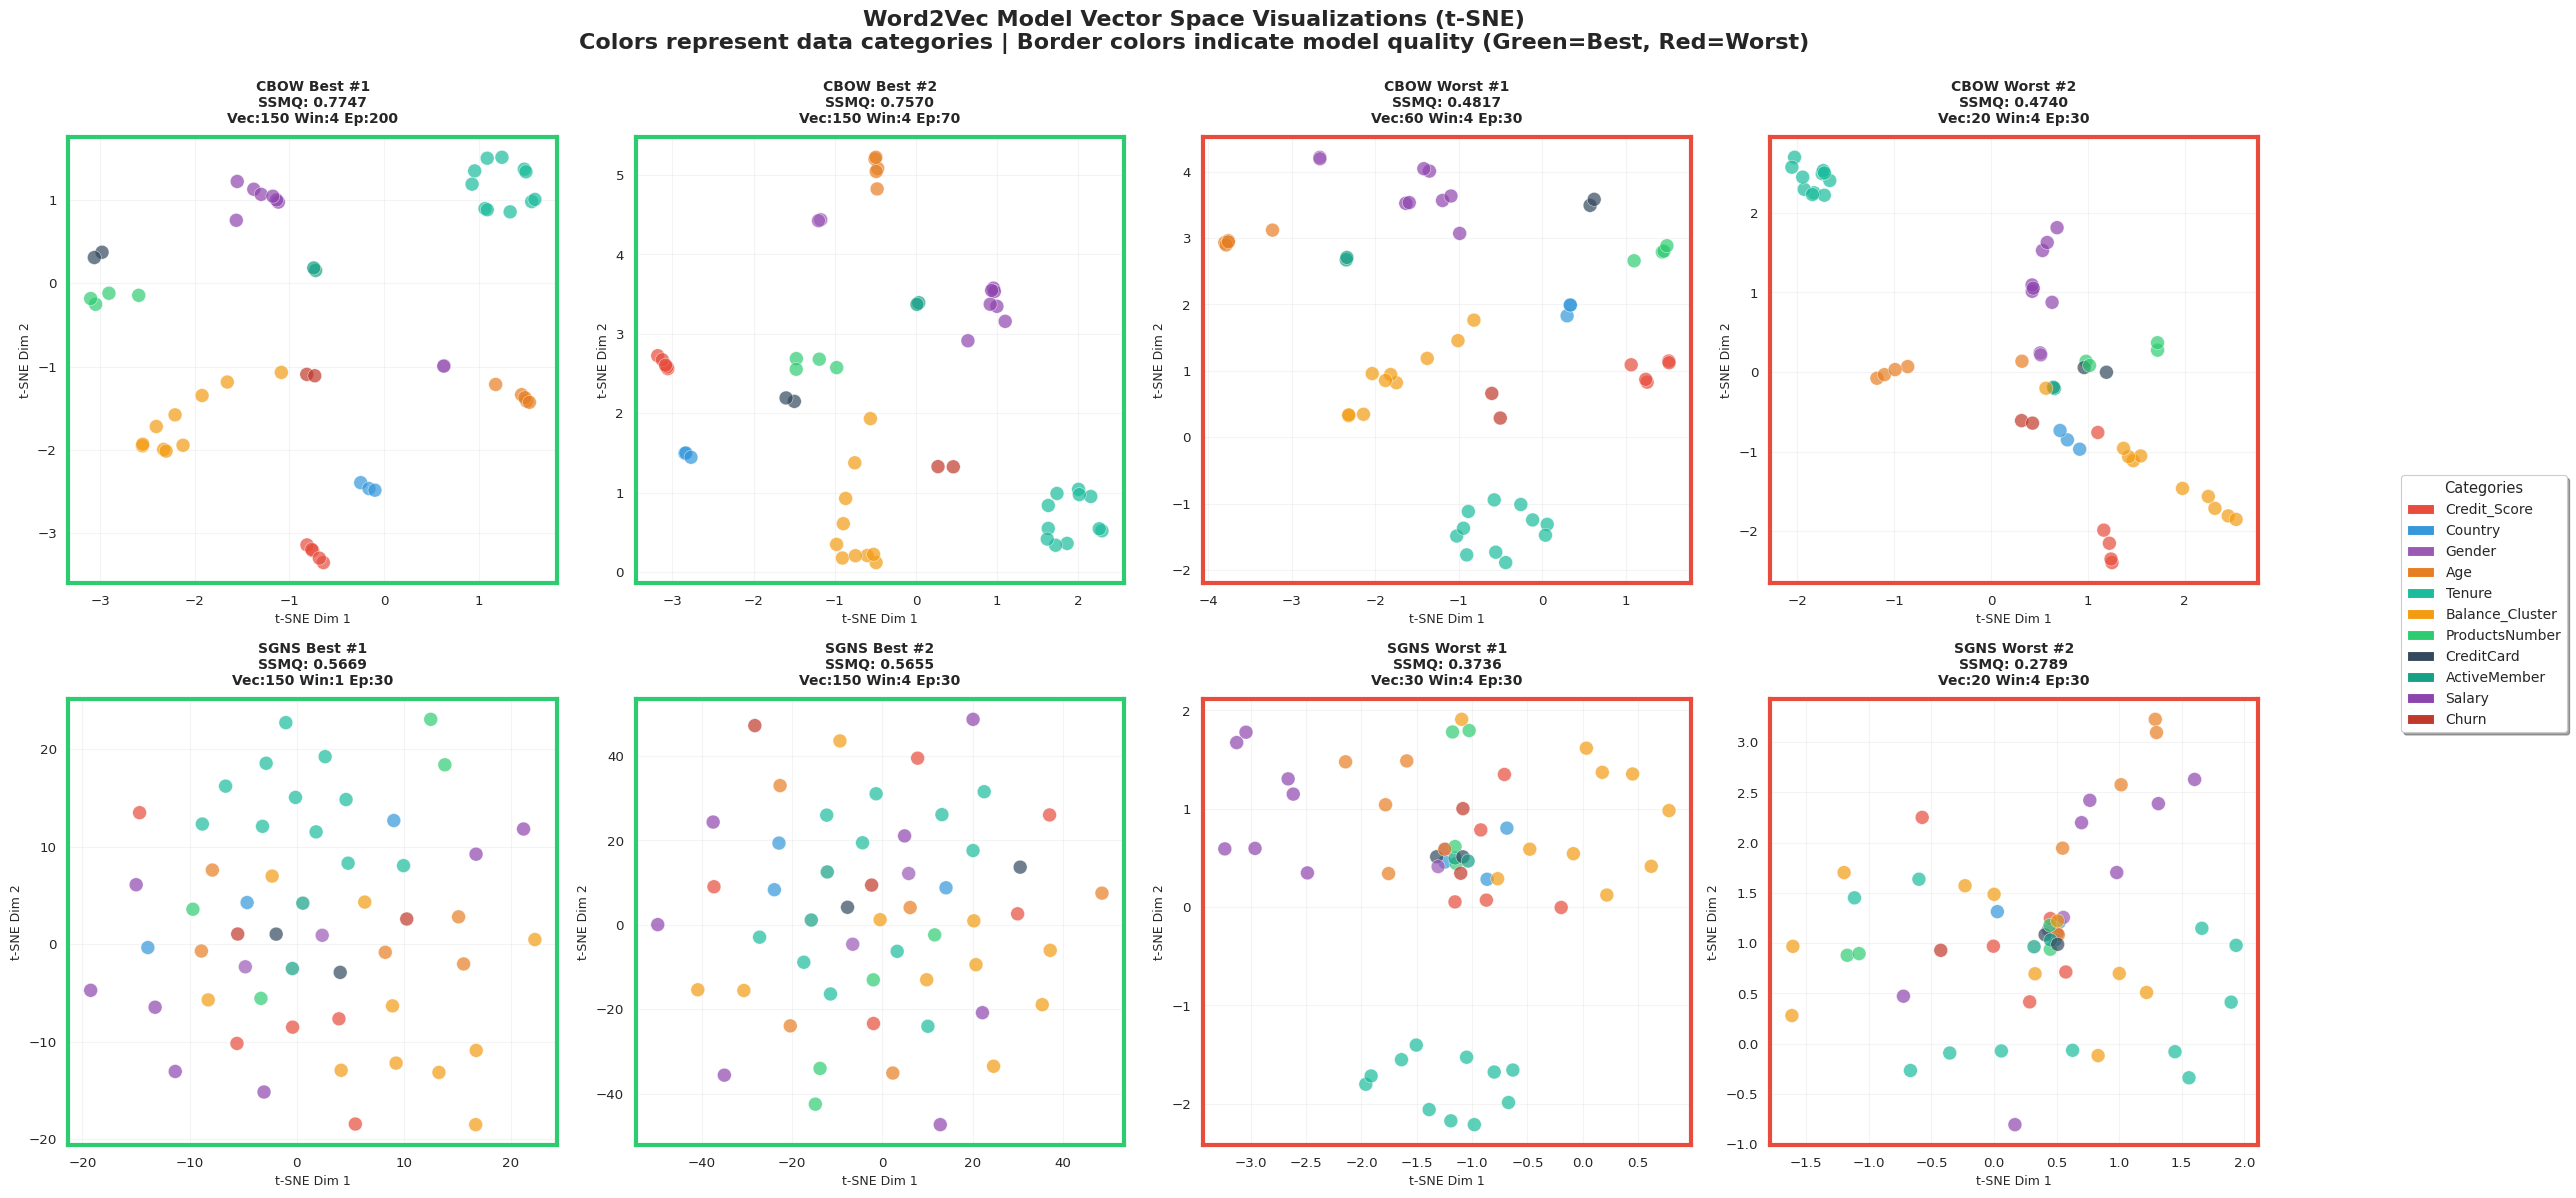


INDIVIDUAL VISUALIZATIONS COMPLETE



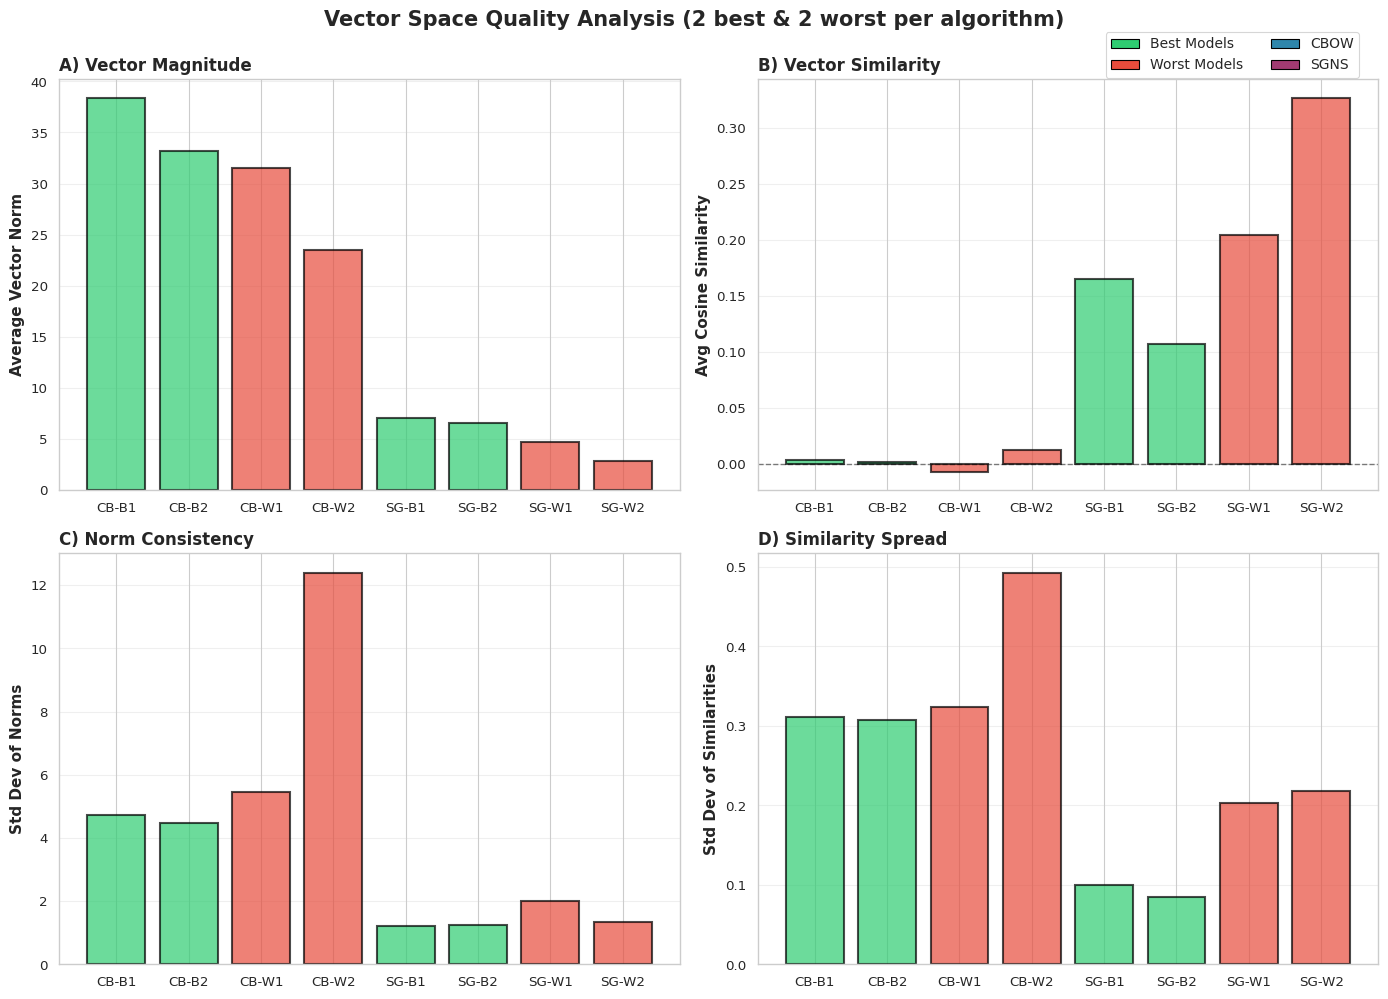


VECTOR SPACE STATISTICS SUMMARY

Model      Algorithm Quality  Avg Norm     Std Norm     Avg Sim      Std Sim     
--------------------------------------------------------------------------------
CB-B1      CBOW     Best     38.3307      4.7443       0.0038       0.3109      
CB-B2      CBOW     Best     33.2280      4.4922       0.0019       0.3071      
CB-W1      CBOW     Worst    31.5594      5.4456       -0.0068      0.3237      
CB-W2      CBOW     Worst    23.4778      12.3994      0.0128       0.4928      
SG-B1      SGNS     Best     7.0773       1.2237       0.1647       0.0999      
SG-B2      SGNS     Best     6.6241       1.2360       0.1070       0.0852      
SG-W1      SGNS     Worst    4.7191       1.9935       0.2044       0.2026      
SG-W2      SGNS     Worst    2.8409       1.3531       0.3267       0.2182      


MODEL COMPARISON COMPLETE


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

# Verwende das gleiche Farbschema
COLORS = {
    'CBOW': '#2E86AB',
    'SGNS': '#A23B72',
    'best': '#2ECC71',    # Grün für beste Modelle
    'worst': '#E74C3C',   # Rot für schlechteste Modelle
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

# ==================================================================================
# SCHRITT 1: Finde 2 beste und 2 schlechteste CBOW- und SGNS-Modelle
# ==================================================================================

# Annahme: models_sorted existiert bereits aus vorherigem Code
# Falls nicht, hier nochmal erstellen:
models_list = []
for result in test_results:
    ssmq_value = None
    if 'ssmq' in result and result['ssmq'] is not None:
        ssmq_value = float(result['ssmq'])
    
    if ssmq_value is None:
        continue
    
    # Speichere auch Referenz zum ursprünglichen Result-Objekt
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    model_data = {
        'ssmq': ssmq_value,
        'nd': nd_value if nd_value is not None else 0.0,
        'fc': float(result.get('fc', 0.0)),
        'rs_mean': float(result.get('rs_mean', 0.0)),
        'algorithm': result['params'].get('Algorithmus', 'Unknown'),
        'vector_size': result['params'].get('Vector Size', 'N/A'),
        'window': result['params'].get('Window', 'N/A'),
        'epochs': result['params'].get('Epochs', 'N/A'),
        'result_ref': result  # Referenz zum Original für Vektor-Zugriff
    }
    
    models_list.append(model_data)

# Trenne Modelle nach Algorithmus
cbow_models = [m for m in models_list if m['algorithm'].upper() == 'CBOW']
sgns_models = [m for m in models_list if m['algorithm'].upper() == 'SGNS']

# Sortiere nach SSMQ (absteigend)
cbow_sorted = sorted(cbow_models, key=lambda x: x['ssmq'], reverse=True)
sgns_sorted = sorted(sgns_models, key=lambda x: x['ssmq'], reverse=True)

# Wähle 2 beste und 2 schlechteste für jeden Algorithmus
best_2_cbow = cbow_sorted[:2]
worst_2_cbow = cbow_sorted[-2:] if len(cbow_sorted) >= 2 else []
best_2_sgns = sgns_sorted[:2]
worst_2_sgns = sgns_sorted[-2:] if len(sgns_sorted) >= 2 else []

# Kombiniere alle ausgewählten Modelle
selected_models = best_2_cbow + worst_2_cbow + best_2_sgns + worst_2_sgns

print("\n" + "="*100)
print("SELECTED MODELS COMPARISON (2 best & 2 worst per algorithm)")
print("="*100 + "\n")

print("BEST 2 CBOW MODELS:")
for i, model in enumerate(best_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 CBOW MODELS:")
for i, model in enumerate(worst_2_cbow, 1):
    print(f"  #{i}: CBOW | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nBEST 2 SGNS MODELS:")
for i, model in enumerate(best_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

print("\nWORST 2 SGNS MODELS:")
for i, model in enumerate(worst_2_sgns, 1):
    print(f"  #{i}: SGNS | SSMQ: {model['ssmq']:.4f} | "
          f"Vec: {model['vector_size']}, Win: {model['window']}, Epochs: {model['epochs']}")

# ==================================================================================
# SCHRITT 2: Extrahiere Word Vectors (falls verfügbar im result)
# ==================================================================================

def extract_word_vectors(model_data):
    """
    Extrahiert Word Vectors aus dem Gensim Word2Vec Modell.
    Filtert alle Wörter heraus, die "key_" (kleingeschrieben) im Namen enthalten.
    """
    result = model_data['result_ref']
    
    # Gensim Word2Vec Model aus 'used_model'
    if 'used_model' in result and 'model_object' in result['used_model']:
        model = result['used_model']['model_object']
        
        if hasattr(model, 'wv'):
            # Alle Wörter und ihre Vektoren
            all_vocab = list(model.wv.key_to_index.keys())
            
            # Filtere Wörter, die "key_" enthalten (case-insensitive für Sicherheit)
            filtered_vocab = [word for word in all_vocab if 'key_' not in word.lower()]
            
            if len(filtered_vocab) == 0:
                print(f"⚠️ Alle Wörter wurden gefiltert (nur key_* vorhanden)")
                return None, None
            
            # Extrahiere nur die gefilterten Vektoren
            filtered_indices = [model.wv.key_to_index[word] for word in filtered_vocab]
            filtered_vectors = model.wv.vectors[filtered_indices]
            
            # Debug-Ausgabe
            filtered_count = len(all_vocab) - len(filtered_vocab)
            print(f"   Total words: {len(all_vocab)}, Filtered (containing 'key_'): {filtered_count}, Kept: {len(filtered_vocab)}")
            
            # Zeige einige Beispiele der gefilterten und behaltenen Wörter
            if filtered_count > 0:
                key_words = [w for w in all_vocab if 'key_' in w.lower()][:5]
                print(f"   Examples of filtered words: {key_words}")
            
            kept_words = filtered_vocab[:5]
            print(f"   Examples of kept words: {kept_words}")
            
            return filtered_vectors, filtered_vocab
    
    print(f"⚠️ Keine Vektoren gefunden für Modell {model_data['algorithm']}")
    return None, None


def get_category_color(word):
    """
    Bestimmt die Farbe basierend auf der Kategorie (Präfix vor dem ersten Unterstrich).
    Format: [Kategorie]_Wert → z.B. Credit_Score_Fair, Country_France, Gender_Female
    """
    # Kategorie-Farbschema
    category_colors = {
        'Credit_Score': '#E74C3C',      # Rot
        'Country': '#3498DB',           # Blau
        'Gender': '#9B59B6',            # Lila
        'Age': '#E67E22',               # Orange
        'Tenure': '#1ABC9C',            # Türkis
        'Balance_Cluster': '#F39C12',   # Gelb-Orange
        'ProductsNumber': '#2ECC71',    # Grün
        'CreditCard': '#34495E',        # Dunkelgrau
        'ActiveMember': '#16A085',      # Dunkel-Türkis
        'Salary': '#8E44AD',            # Dunkel-Lila
        'Churn': '#C0392B',             # Dunkel-Rot
    }
    
    # Versuche Kategorie zu extrahieren
    # Für Balance_Cluster_X müssen wir die ersten zwei Teile nehmen
    parts = word.split('_')
    
    # Spezialfall: Balance_Cluster
    if len(parts) >= 2 and parts[0] == 'Balance' and parts[1] == 'Cluster':
        category = 'Balance_Cluster'
    # Normalfall: Erste Teil ist die Kategorie
    elif len(parts) >= 1:
        category = parts[0]
        # Für zweistufige Kategorien wie Credit_Score
        if len(parts) >= 2 and f"{parts[0]}_{parts[1]}" in category_colors:
            category = f"{parts[0]}_{parts[1]}"
    else:
        category = None
    
    # Gib Farbe zurück oder Standard-Grau
    return category_colors.get(category, '#95A5A6')  # Standard: Grau

# Sammle Vektoren für ausgewählte Modelle
cbow_best_vectors = []
cbow_worst_vectors = []
sgns_best_vectors = []
sgns_worst_vectors = []

cbow_best_vocab = []
cbow_worst_vocab = []
sgns_best_vocab = []
sgns_worst_vocab = []

print("\n" + "="*100)
print("EXTRACTING WORD VECTORS...")
print("="*100 + "\n")

# CBOW beste Modelle
print("CBOW Best Models:")
for i, model in enumerate(best_2_cbow):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_best_vectors.append(vectors)
        cbow_best_vocab.append(vocab)
        print(f"✓ CBOW Best Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ CBOW Best Model #{i+1}: No vectors found")

# CBOW schlechteste Modelle
print("\nCBOW Worst Models:")
for i, model in enumerate(worst_2_cbow):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        cbow_worst_vectors.append(vectors)
        cbow_worst_vocab.append(vocab)
        print(f"✓ CBOW Worst Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ CBOW Worst Model #{i+1}: No vectors found")

# SGNS beste Modelle
print("\nSGNS Best Models:")
for i, model in enumerate(best_2_sgns):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_best_vectors.append(vectors)
        sgns_best_vocab.append(vocab)
        print(f"✓ SGNS Best Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ SGNS Best Model #{i+1}: No vectors found")

# SGNS schlechteste Modelle
print("\nSGNS Worst Models:")
for i, model in enumerate(worst_2_sgns):
    vectors, vocab = extract_word_vectors(model)
    if vectors is not None:
        sgns_worst_vectors.append(vectors)
        sgns_worst_vocab.append(vocab)
        print(f"✓ SGNS Worst Model #{i+1}: {vectors.shape[0]} words, {vectors.shape[1]} dimensions")
    else:
        print(f"✗ SGNS Worst Model #{i+1}: No vectors found")

# ==================================================================================
# FIGURE 1: Separate Vector Space Visualization für jedes Modell (8 Modelle)
# ==================================================================================

# Kombiniere alle Vektoren für die Visualisierung
all_vectors_to_plot = []
vector_categories = []

# CBOW Beste Modelle
for i in range(min(2, len(cbow_best_vectors))):
    all_vectors_to_plot.append({
        'vectors': cbow_best_vectors[i],
        'vocab': cbow_best_vocab[i],
        'model_info': best_2_cbow[i],
        'algorithm': 'CBOW',
        'quality': 'Best',
        'rank': i + 1,
        'border_color': COLORS['best'],
        'plot_color': COLORS['CBOW']
    })

# CBOW Schlechteste Modelle
for i in range(min(2, len(cbow_worst_vectors))):
    all_vectors_to_plot.append({
        'vectors': cbow_worst_vectors[i],
        'vocab': cbow_worst_vocab[i],
        'model_info': worst_2_cbow[i],
        'algorithm': 'CBOW',
        'quality': 'Worst',
        'rank': i + 1,
        'border_color': COLORS['worst'],
        'plot_color': COLORS['CBOW']
    })

# SGNS Beste Modelle
for i in range(min(2, len(sgns_best_vectors))):
    all_vectors_to_plot.append({
        'vectors': sgns_best_vectors[i],
        'vocab': sgns_best_vocab[i],
        'model_info': best_2_sgns[i],
        'algorithm': 'SGNS',
        'quality': 'Best',
        'rank': i + 1,
        'border_color': COLORS['best'],
        'plot_color': COLORS['SGNS']
    })

# SGNS Schlechteste Modelle
for i in range(min(2, len(sgns_worst_vectors))):
    all_vectors_to_plot.append({
        'vectors': sgns_worst_vectors[i],
        'vocab': sgns_worst_vocab[i],
        'model_info': worst_2_sgns[i],
        'algorithm': 'SGNS',
        'quality': 'Worst',
        'rank': i + 1,
        'border_color': COLORS['worst'],
        'plot_color': COLORS['SGNS']
    })

if all_vectors_to_plot:
    print(f"\n{'='*100}")
    print(f"CREATING INDIVIDUAL MODEL VISUALIZATIONS ({len(all_vectors_to_plot)} separate plots)")
    print(f"{'='*100}\n")
    
    # Erstelle 8 separate Plots (2 Reihen x 4 Spalten)
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle('Word2Vec Model Vector Space Visualizations (t-SNE)\n' + 
                 'Colors represent data categories | Border colors indicate model quality (Green=Best, Red=Worst)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    axes = axes.flatten()
    
    for idx, model_data in enumerate(all_vectors_to_plot):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        vectors = model_data['vectors']
        vocab = model_data['vocab']
        model_info = model_data['model_info']
        algorithm = model_data['algorithm']
        quality = model_data['quality']
        rank = model_data['rank']
        border_color = model_data['border_color']
        plot_color = model_data['plot_color']
        
        # Limitiere auf max 2000 Wörter für Performance
        max_words = min(2000, len(vectors))
        sample_indices = np.random.choice(len(vectors), max_words, replace=False)
        vectors_sample = vectors[sample_indices]
        vocab_sample = [vocab[i] for i in sample_indices]
        
        print(f"Processing {algorithm} {quality} Model #{rank}: {max_words} words...")
        
        # t-SNE Projektion
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_words-1), max_iter=500)
        vectors_2d = tsne.fit_transform(vectors_sample)
        
        # Bestimme Farben basierend auf Kategorien
        point_colors = [get_category_color(word) for word in vocab_sample]
        
        # Plot Punkte mit kategorie-basierten Farben
        scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                            c=point_colors, alpha=0.7, s=100, edgecolors='white', linewidth=0.4)
        
        # Annotiere 20 zufällige Wörter
        num_annotations = 0  # min(20, len(vocab_sample))
        annotation_indices = np.random.choice(len(vocab_sample), num_annotations, replace=False)
        
        for ann_idx in annotation_indices:
            word = vocab_sample[ann_idx]
            word_color = get_category_color(word)
            ax.annotate(word, 
                       (vectors_2d[ann_idx, 0], vectors_2d[ann_idx, 1]),
                       fontsize=7, alpha=0.9, color='black',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor=word_color, 
                                alpha=0.5, edgecolor='black', linewidth=0.5))
        
        # Titel und Labels
        title = f"{algorithm} {quality} #{rank}\n"
        title += f"SSMQ: {model_info['ssmq']:.4f}\n"
        title += f"Vec:{model_info['vector_size']} Win:{model_info['window']} Ep:{model_info['epochs']}"
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('t-SNE Dim 1', fontsize=9)
        ax.set_ylabel('t-SNE Dim 2', fontsize=9)
        ax.grid(True, alpha=0.2)
        
        # Farbiger Rahmen um den Plot (Best/Worst Indikator)
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
    
    # Entferne leere Subplots falls weniger als 8 Modelle
    for idx in range(len(all_vectors_to_plot), len(axes)):
        axes[idx].set_visible(False)
    
    # Erstelle Legende für Kategorien
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Credit_Score'),
        Patch(facecolor='#3498DB', label='Country'),
        Patch(facecolor='#9B59B6', label='Gender'),
        Patch(facecolor='#E67E22', label='Age'),
        Patch(facecolor='#1ABC9C', label='Tenure'),
        Patch(facecolor='#F39C12', label='Balance_Cluster'),
        Patch(facecolor='#2ECC71', label='ProductsNumber'),
        Patch(facecolor='#34495E', label='CreditCard'),
        Patch(facecolor='#16A085', label='ActiveMember'),
        Patch(facecolor='#8E44AD', label='Salary'),
        Patch(facecolor='#C0392B', label='Churn'),
    ]
    
    # Legende rechts neben den Plots
    fig.legend(handles=legend_elements, loc='center left', 
              bbox_to_anchor=(1.0, 0.5), fontsize=10, title='Categories',
              frameon=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 0.95, 1])  # Platz für Legende lassen
    plt.show()
    
    print(f"\n{'='*100}")
    print("INDIVIDUAL VISUALIZATIONS COMPLETE")
    print(f"{'='*100}\n")

# ==================================================================================
# FIGURE 2: Vector Space Quality Metrics
# ==================================================================================

def compute_vector_statistics(vectors):
    """Berechnet Statistiken über den Vektorraum"""
    # Durchschnittliche Norm
    norms = np.linalg.norm(vectors, axis=1)
    avg_norm = np.mean(norms)
    std_norm = np.std(norms)
    
    # Durchschnittliche Kosinus-Ähnlichkeit (Sampling für Performance)
    sample_size = min(1000, len(vectors))
    sample_indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[sample_indices]
    
    # Normalisiere für Kosinus-Ähnlichkeit
    sample_vectors_norm = sample_vectors / (np.linalg.norm(sample_vectors, axis=1, keepdims=True) + 1e-8)
    similarity_matrix = np.dot(sample_vectors_norm, sample_vectors_norm.T)
    
    # Entferne Diagonale (Selbst-Ähnlichkeit)
    mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
    avg_similarity = np.mean(similarity_matrix[mask])
    std_similarity = np.std(similarity_matrix[mask])
    
    return {
        'avg_norm': avg_norm,
        'std_norm': std_norm,
        'avg_similarity': avg_similarity,
        'std_similarity': std_similarity
    }

# Berechne Statistiken für alle Modelle
all_stats = []
all_labels = []

# CBOW Beste Modelle
for i, vectors in enumerate(cbow_best_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'CB-B{i+1}')

# CBOW Schlechteste Modelle
for i, vectors in enumerate(cbow_worst_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'CB-W{i+1}')

# SGNS Beste Modelle
for i, vectors in enumerate(sgns_best_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'SG-B{i+1}')

# SGNS Schlechteste Modelle
for i, vectors in enumerate(sgns_worst_vectors):
    stats = compute_vector_statistics(vectors)
    all_stats.append(stats)
    all_labels.append(f'SG-W{i+1}')

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis (2 best & 2 worst per algorithm)', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    # Farben für die Balken
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):
            bar_colors.append('#2ECC71')  # Grün für CBOW Best
        elif label.startswith('CB-W'):
            bar_colors.append('#E74C3C')  # Rot für CBOW Worst
        elif label.startswith('SG-B'):
            bar_colors.append('#2ECC71')  # Grün für SGNS Best
        elif label.startswith('SG-W'):
            bar_colors.append('#E74C3C')  # Rot für SGNS Worst
    
    # Plot 1: Vector Norms
    ax1 = axes[0, 0]
    avg_norms = [s['avg_norm'] for s in all_stats]
    
    bars = ax1.bar(all_labels, avg_norms, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Average Vector Norm', fontsize=11, fontweight='bold')
    ax1.set_title('A) Vector Magnitude', fontsize=12, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Cosine Similarity Distribution
    ax2 = axes[0, 1]
    avg_sims = [s['avg_similarity'] for s in all_stats]
    
    bars = ax2.bar(all_labels, avg_sims, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Avg Cosine Similarity', fontsize=11, fontweight='bold')
    ax2.set_title('B) Vector Similarity', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Plot 3: Norm Standard Deviation
    ax3 = axes[1, 0]
    std_norms = [s['std_norm'] for s in all_stats]
    
    bars = ax3.bar(all_labels, std_norms, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Std Dev of Norms', fontsize=11, fontweight='bold')
    ax3.set_title('C) Norm Consistency', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Similarity Standard Deviation
    ax4 = axes[1, 1]
    std_sims = [s['std_similarity'] for s in all_stats]
    
    bars = ax4.bar(all_labels, std_sims, color=bar_colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Std Dev of Similarities', fontsize=11, fontweight='bold')
    ax4.set_title('D) Similarity Spread', fontsize=12, fontweight='bold', loc='left')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Legende hinzufügen
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ECC71', edgecolor='black', label='Best Models'),
        Patch(facecolor='#E74C3C', edgecolor='black', label='Worst Models'),
        Patch(facecolor=COLORS['CBOW'], edgecolor='black', label='CBOW'),
        Patch(facecolor=COLORS['SGNS'], edgecolor='black', label='SGNS')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98), ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print("\n" + "="*100)
    print("VECTOR SPACE STATISTICS SUMMARY")
    print("="*100)
    print(f"\n{'Model':<10} {'Algorithm':<8} {'Quality':<8} {'Avg Norm':<12} {'Std Norm':<12} {'Avg Sim':<12} {'Std Sim':<12}")
    print("-" * 80)
    
    for i, (label, stats) in enumerate(zip(all_labels, all_stats)):
        algorithm = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "Best" if label.endswith('B1') or label.endswith('B2') else "Worst"
        print(f"{label:<10} {algorithm:<8} {quality:<8} {stats['avg_norm']:<12.4f} {stats['std_norm']:<12.4f} "
              f"{stats['avg_similarity']:<12.4f} {stats['std_similarity']:<12.4f}")
    
    print("="*100 + "\n")

else:
    print("\n⚠️ Vektoren konnten nicht extrahiert werden.")
    print("Bitte passe die Funktion 'extract_word_vectors()' an deine Datenstruktur an.")
    print("Mögliche Speicherorte: result['model'].wv.vectors, result['vectors'], result['embeddings']")

print("\n" + "="*100)
print("MODEL COMPARISON COMPLETE")
print("="*100)

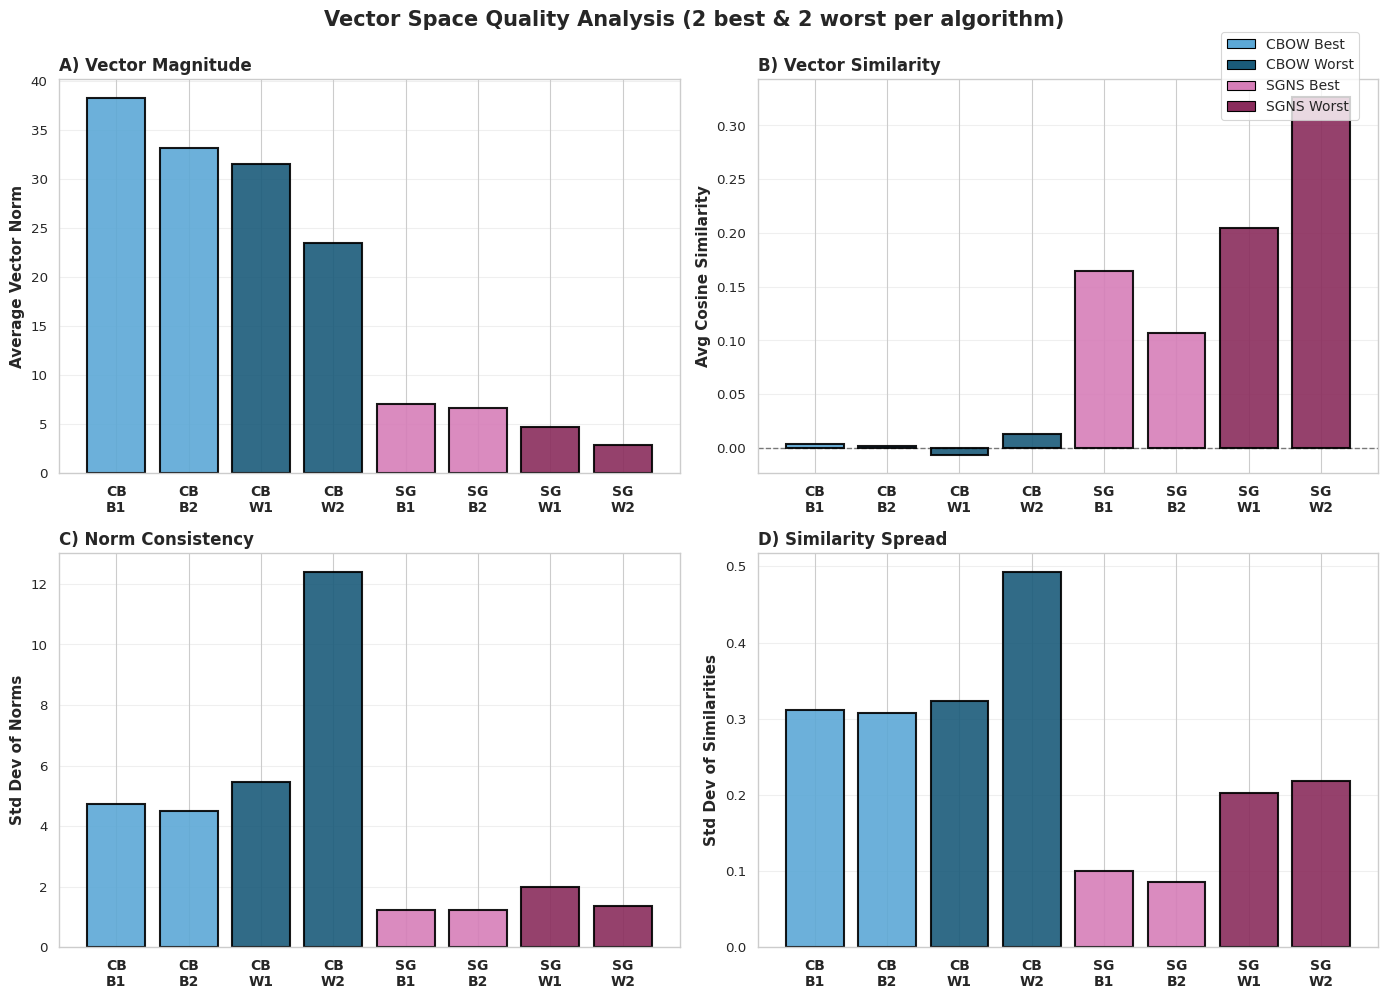


VECTOR SPACE STATISTICS SUMMARY

Model      Algorithm Quality  Avg Norm     Std Norm     Avg Sim      Std Sim     
--------------------------------------------------------------------------------
CB-B1      CBOW     Best     38.3307      4.7443       0.0038       0.3109      
CB-B2      CBOW     Best     33.2280      4.4922       0.0019       0.3071      
CB-W1      CBOW     Best     31.5594      5.4456       -0.0068      0.3237      
CB-W2      CBOW     Best     23.4778      12.3994      0.0128       0.4928      
SG-B1      SGNS     Best     7.0773       1.2237       0.1647       0.0999      
SG-B2      SGNS     Best     6.6241       1.2360       0.1070       0.0852      
SG-W1      SGNS     Worst    4.7191       1.9935       0.2044       0.2026      
SG-W2      SGNS     Worst    2.8409       1.3531       0.3267       0.2182      



In [12]:
# Nur den relevanten Teil für die FIGURE 2 anpassen:

# ==================================================================================
# FIGURE 2: Vector Space Quality Metrics (mit kombinierter Farbkodierung)
# ==================================================================================

# [Vorheriger Code bleibt gleich bis zur Farbdefinition...]

if all_stats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Vector Space Quality Analysis (2 best & 2 worst per algorithm)', 
                 fontsize=15, fontweight='bold', y=0.995)
    
    # KOMBINIERTE FARBEN: Algorithmus + Qualität
    # Für Best: Hellerer Ton des Algorithmus-Farbtons
    # Für Worst: Dunklerer Ton des Algorithmus-Farbtons
    bar_colors = []
    for label in all_labels:
        if label.startswith('CB-B'):  # CBOW Best
            # Hellblau für CBOW Best
            bar_colors.append('#5CA8D6')  
        elif label.startswith('CB-W'):  # CBOW Worst
            # Dunkelblau für CBOW Worst
            bar_colors.append('#1A5B7A')  
        elif label.startswith('SG-B'):  # SGNS Best
            # Hellrosa für SGNS Best
            bar_colors.append('#D67EB8')  
        elif label.startswith('SG-W'):  # SGNS Worst
            # Dunkelrosa für SGNS Worst
            bar_colors.append('#8A2C5C')  
    
    # Plot 1: Vector Norms
    ax1 = axes[0, 0]
    avg_norms = [s['avg_norm'] for s in all_stats]
    
    bars = ax1.bar(all_labels, avg_norms, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Average Vector Norm', fontsize=11, fontweight='bold')
    ax1.set_title('A) Vector Magnitude', fontsize=12, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Verbesserte x-Achsenbeschriftung mit Algorithmus-Info
    xtick_labels = []
    for label in all_labels:
        algo = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "B" if 'B' in label[-2] else "W"
        num = label[-1]
        xtick_labels.append(f"{algo[:2]}\n{quality}{num}")
    
    ax1.set_xticks(range(len(all_labels)))
    ax1.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 2: Cosine Similarity Distribution
    ax2 = axes[0, 1]
    avg_sims = [s['avg_similarity'] for s in all_stats]
    
    bars = ax2.bar(all_labels, avg_sims, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Avg Cosine Similarity', fontsize=11, fontweight='bold')
    ax2.set_title('B) Vector Similarity', fontsize=12, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xticks(range(len(all_labels)))
    ax2.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 3: Norm Standard Deviation
    ax3 = axes[1, 0]
    std_norms = [s['std_norm'] for s in all_stats]
    
    bars = ax3.bar(all_labels, std_norms, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax3.set_ylabel('Std Dev of Norms', fontsize=11, fontweight='bold')
    ax3.set_title('C) Norm Consistency', fontsize=12, fontweight='bold', loc='left')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xticks(range(len(all_labels)))
    ax3.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # Plot 4: Similarity Standard Deviation
    ax4 = axes[1, 1]
    std_sims = [s['std_similarity'] for s in all_stats]
    
    bars = ax4.bar(all_labels, std_sims, color=bar_colors, alpha=0.9, 
                   edgecolor='black', linewidth=1.5)
    ax4.set_ylabel('Std Dev of Similarities', fontsize=11, fontweight='bold')
    ax4.set_title('D) Similarity Spread', fontsize=12, fontweight='bold', loc='left')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_xticks(range(len(all_labels)))
    ax4.set_xticklabels(xtick_labels, fontsize=10, fontweight='bold')
    
    # VERBESSERTE LEGENDE mit kombinierten Farben
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#5CA8D6', edgecolor='black', label='CBOW Best'),
        Patch(facecolor='#1A5B7A', edgecolor='black', label='CBOW Worst'),
        Patch(facecolor='#D67EB8', edgecolor='black', label='SGNS Best'),
        Patch(facecolor='#8A2C5C', edgecolor='black', label='SGNS Worst')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10, 
              bbox_to_anchor=(0.98, 0.98))
    
    plt.tight_layout()
    plt.show()
    
    # Numerische Zusammenfassung
    print("\n" + "="*100)
    print("VECTOR SPACE STATISTICS SUMMARY")
    print("="*100)
    print(f"\n{'Model':<10} {'Algorithm':<8} {'Quality':<8} {'Avg Norm':<12} {'Std Norm':<12} {'Avg Sim':<12} {'Std Sim':<12}")
    print("-" * 80)
    
    for i, (label, stats) in enumerate(zip(all_labels, all_stats)):
        algorithm = "CBOW" if label.startswith('CB') else "SGNS"
        quality = "Best" if 'B' in label else "Worst"
        print(f"{label:<10} {algorithm:<8} {quality:<8} {stats['avg_norm']:<12.4f} {stats['std_norm']:<12.4f} "
              f"{stats['avg_similarity']:<12.4f} {stats['std_similarity']:<12.4f}")
    
    print("="*100 + "\n")